# Laporan Analisis Data Mining - Kelompok 4 (Telkom University)
### Topik: Analisis Karakteristik Wilayah dan Prediksi Kelas Harga Pasar Properti Melbourne Menggunakan Pendekatan Unsupervised dan Supervised Learning

Notebook ini mendokumentasikan alur pengerjaan lengkap dari pengolahan data Melbourne Housing Market hingga pemodelan dan ekspor model. Metodologi yang digunakan adalah **CRISP-DM** (Cross-Industry Standard Process for Data Mining).


# Bab 1: Pemahaman Data & Inisialisasi (Data Understanding & Load)

Tahap awal dari metodologi CRISP-DM adalah memahami data. Pada tahap ini, kita mengimpor pustaka (*library*) yang diperlukan untuk analisis data, visualisasi, klasterisasi, dan klasifikasi. Pustaka utama meliputi:
- **Pandas** & **NumPy**: Untuk pemrosesan data terstruktur.
- **Matplotlib** & **Seaborn**: Untuk pembuatan grafik.
- **Scikit-learn**: Untuk pemodelan *Machine Learning*.

Selanjutnya, kita memuat dataset **Melbourne Housing Market** dari berkas `Melbourne_Data.csv` dan menampilkan ringkasan informasi awalnya. Kita juga melihat distribusi harga awal menggunakan histogram untuk mengidentifikasi pola kecondongan (*skewness*) harga properti di pasar Melbourne.


Informasi Dataset Awal:
<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  str    
 17  Lattitude      26881 non-null  float6

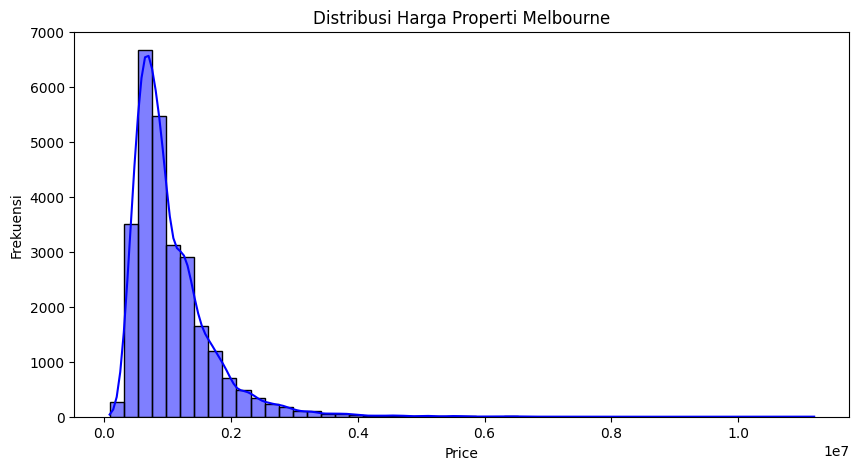

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('Melbourne_Data.csv')

print("Informasi Dataset Awal:")
print(df.info())

plt.figure(figsize=(10, 5))
sns.histplot(df['Price'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribusi Harga Properti Melbourne')
plt.xlabel('Price')
plt.ylabel('Frekuensi')
plt.show()

## 1.1 Statistik Deskriptif Awal
Di bawah ini kita menampilkan statistik ringkasan data (seperti rata-rata, standar deviasi, nilai minimum, median, dan maksimum) untuk variabel numerik dalam dataset. Langkah ini krusial untuk mendeteksi outlier ekstrem yang tidak logis (misalnya luas tanah atau tahun pembuatan yang bernilai janggal).


In [2]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


## 1.2 Identifikasi Data Rumpang (Missing Values)
Sebelum melakukan pemodelan, kita perlu mengidentifikasi kolom mana saja yang memiliki nilai kosong (*null*). Penanganan data kosong sangat penting karena sebagian besar algoritma *machine learning* tidak dapat memproses data dengan nilai kosong (*NaN*).


In [3]:
df.isna().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64

# Bab 2: Eksplorasi Data Analitis (Exploratory Data Analysis - EDA)

Pada bab ini, kita melakukan Exploratory Data Analysis (EDA) yang mendalam sebelum data dibersihkan atau direkayasa. Langkah ini penting untuk memahami distribusi variabel, mendeteksi outlier secara visual, dan menganalisis korelasi antar fitur.

## 2.1 Distribusi Variabel Numerik
Bagan di bawah menggambarkan histogram dan kurva estimasi kepadatan kernel (KDE) untuk masing-masing variabel numerik dalam dataset awal untuk mendeteksi bentuk sebaran data.


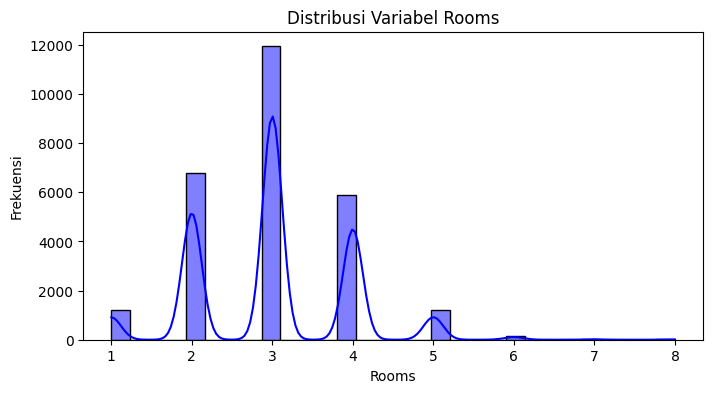

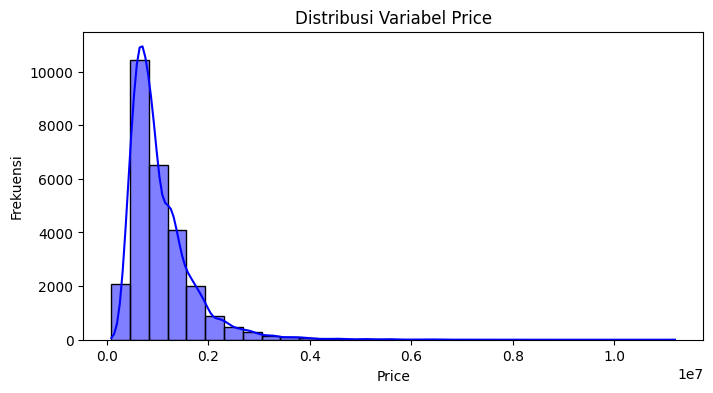

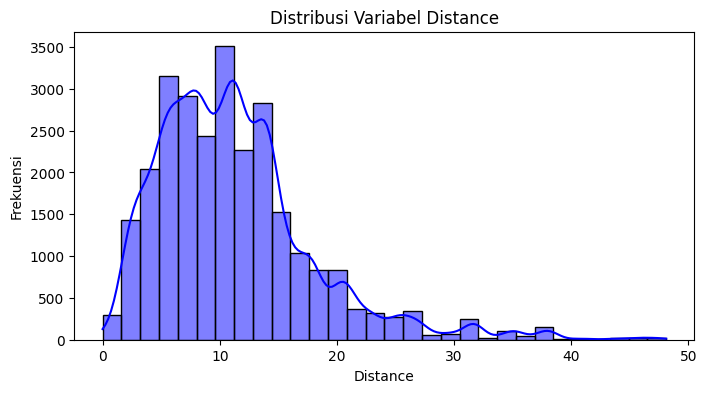

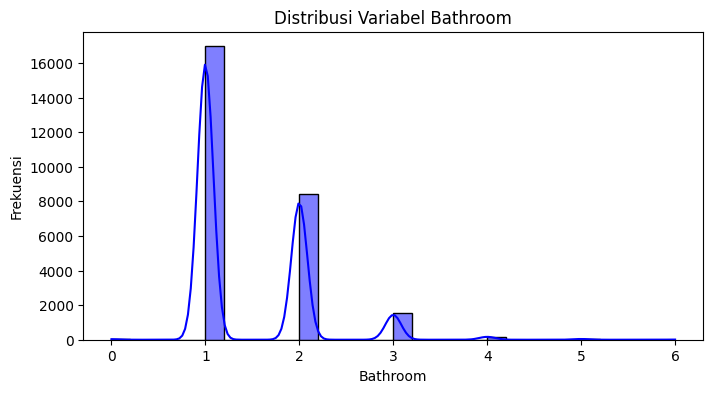

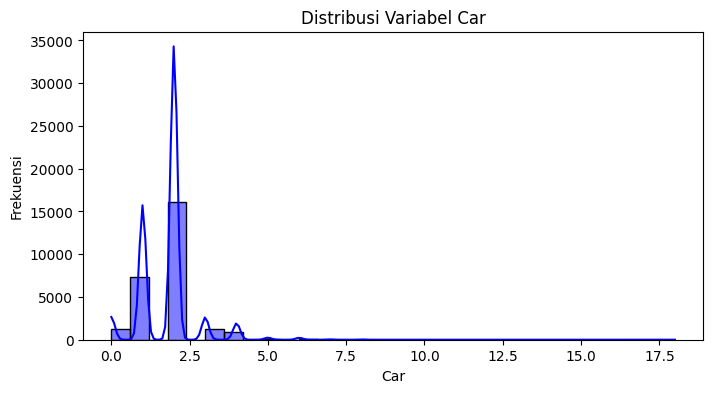

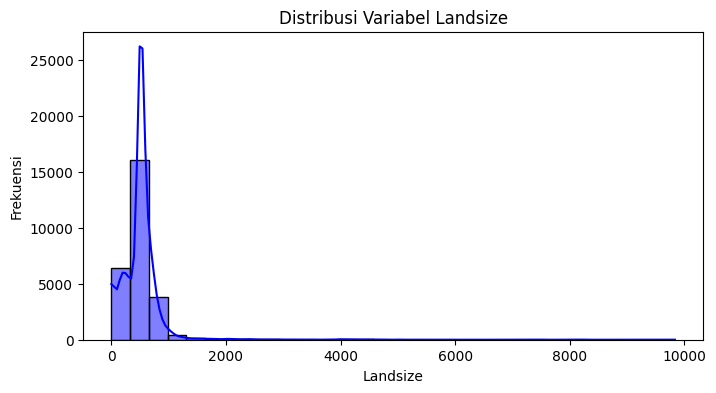

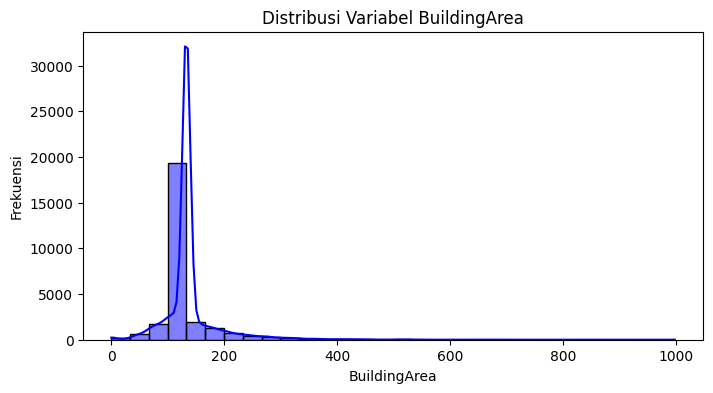

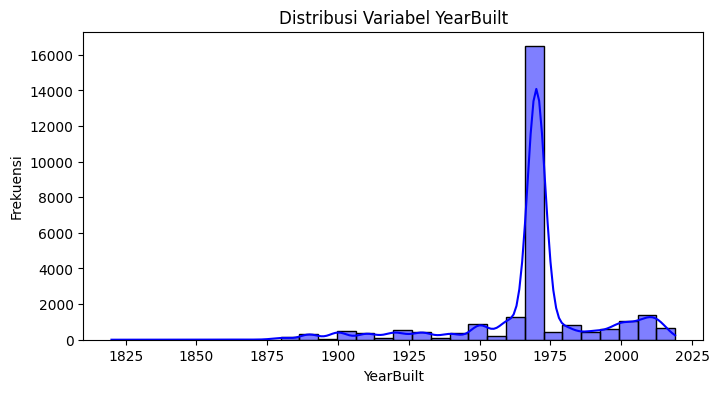

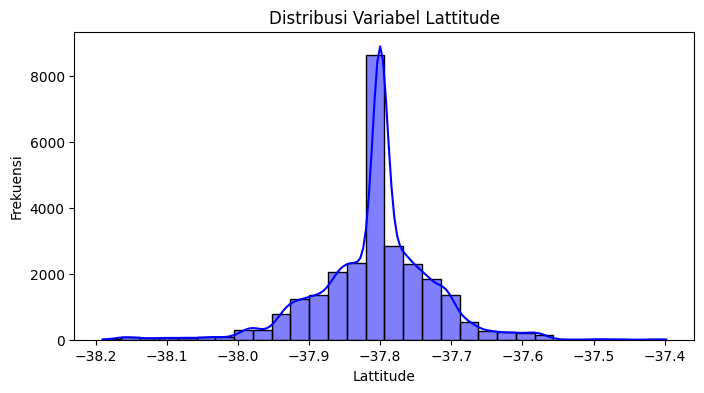

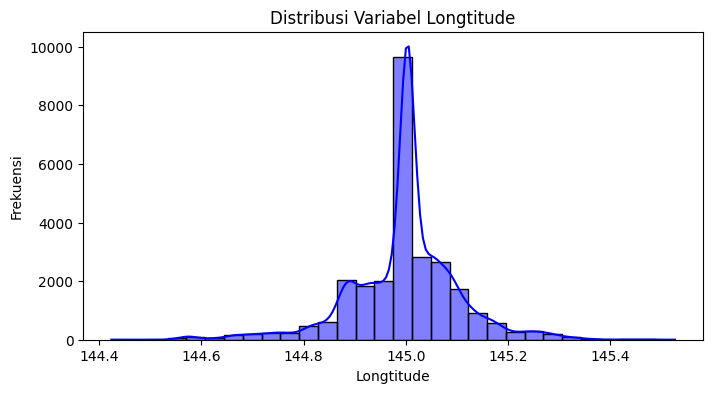

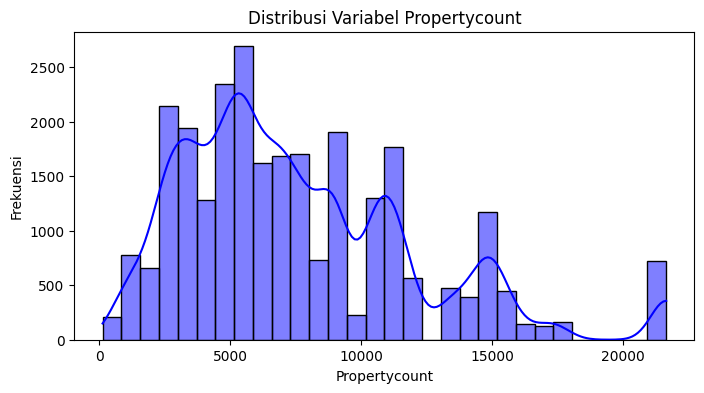

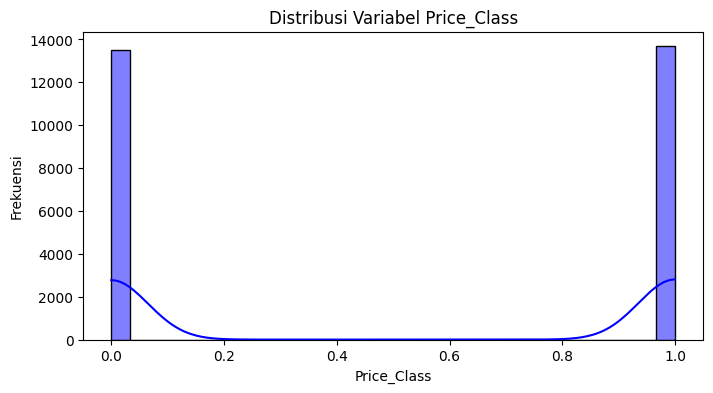

In [8]:
# Visualisasi Distribusi Variabel Numerik

kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns

for col in kolom_numerik:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(),
                 bins=30,
                 kde=True,
                 color='blue')

    plt.title(f'Distribusi Variabel {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## 2.2 Analisis Outlier Menggunakan Boxplot (Data Awal)
Untuk mengidentifikasi pencilan atau outlier ekstrem yang disebabkan oleh kesalahan input data (typo) atau variasi ekstrem, kita memvisualisasikan boxplot fitur-fitur fisik utama langsung dari data mentah.

*Catatan: Kita memplot variabel langsung dari data asli `df` agar memperlihatkan kondisi sebaran data sebelum dilakukan pembersihan.*


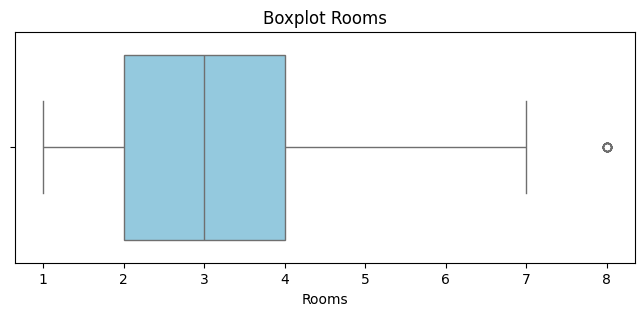

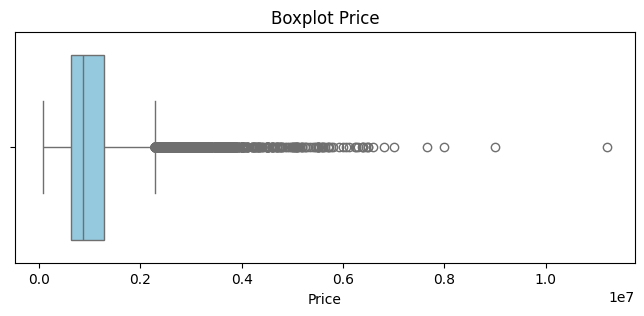

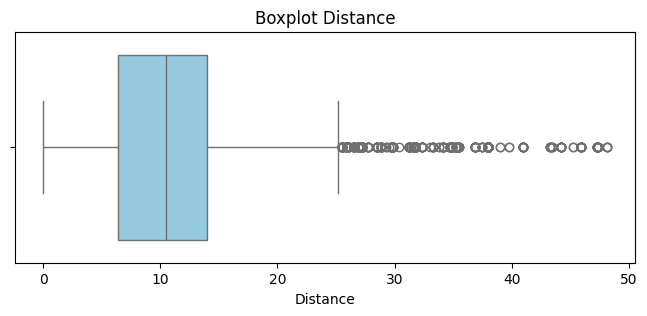

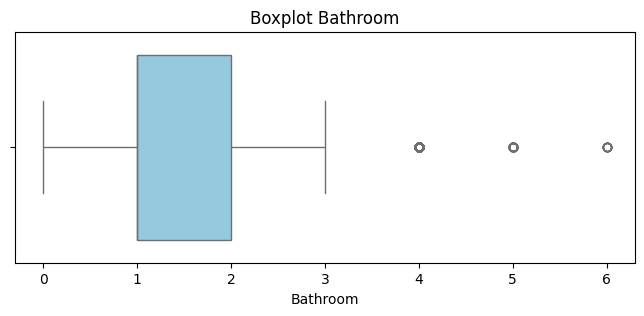

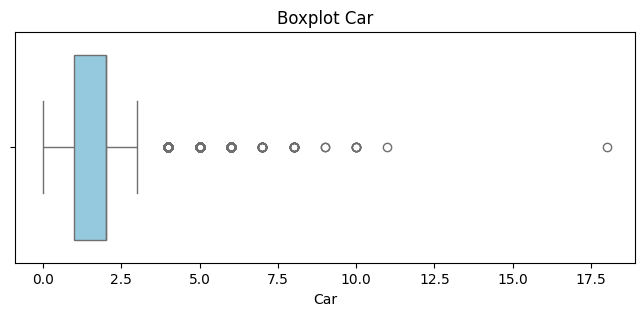

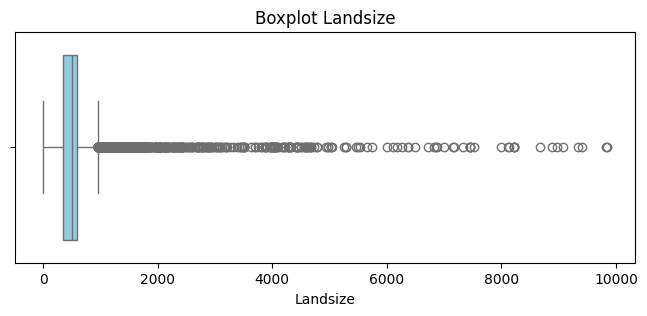

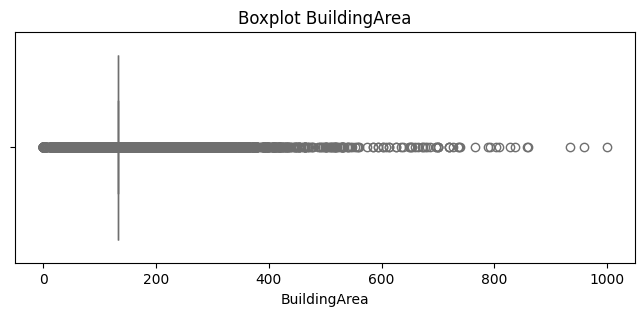

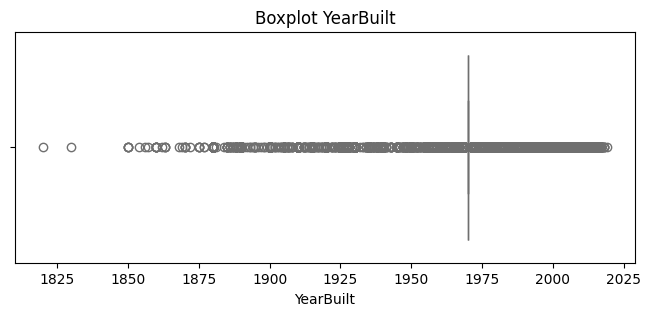

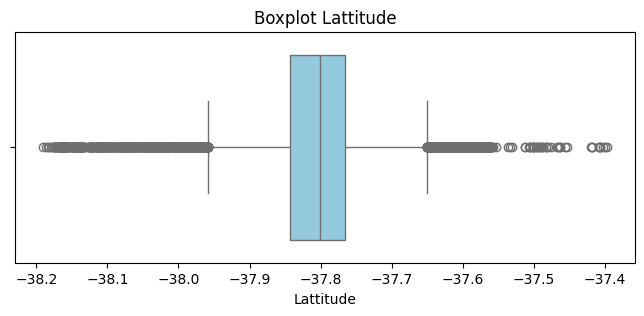

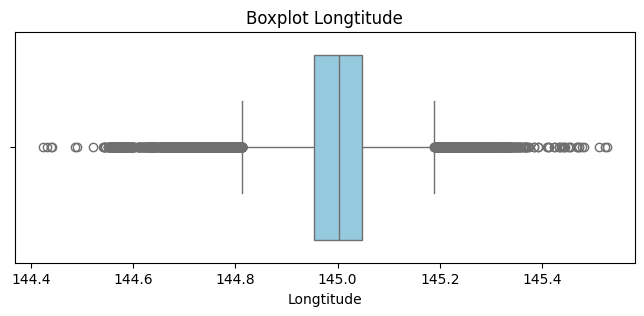

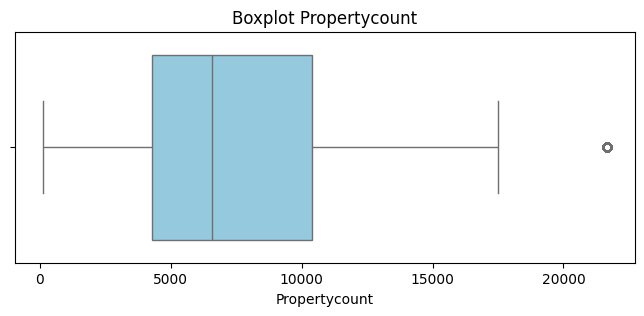

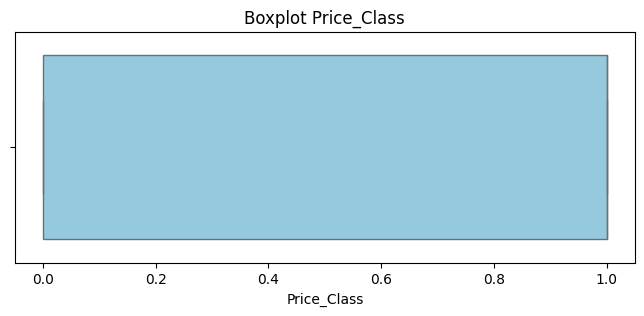

In [9]:
# Visualisasi Boxplot Variabel Numerik

kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns

for col in kolom_numerik:
    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col], color='skyblue')

    plt.title(f'Boxplot {col}')
    plt.xlabel(col)

    plt.show()


## 2.3 Matriks Korelasi (Correlation Heatmap)
Peta panas korelasi ini memperlihatkan nilai koefisien korelasi Pearson antar fitur numerik. Nilai mendekati +1.0 menunjukkan korelasi positif kuat, sedangkan mendekati -1.0 menunjukkan korelasi negatif kuat. Ini membantu kita melihat korelasi fitur fisik terhadap harga jual properti.


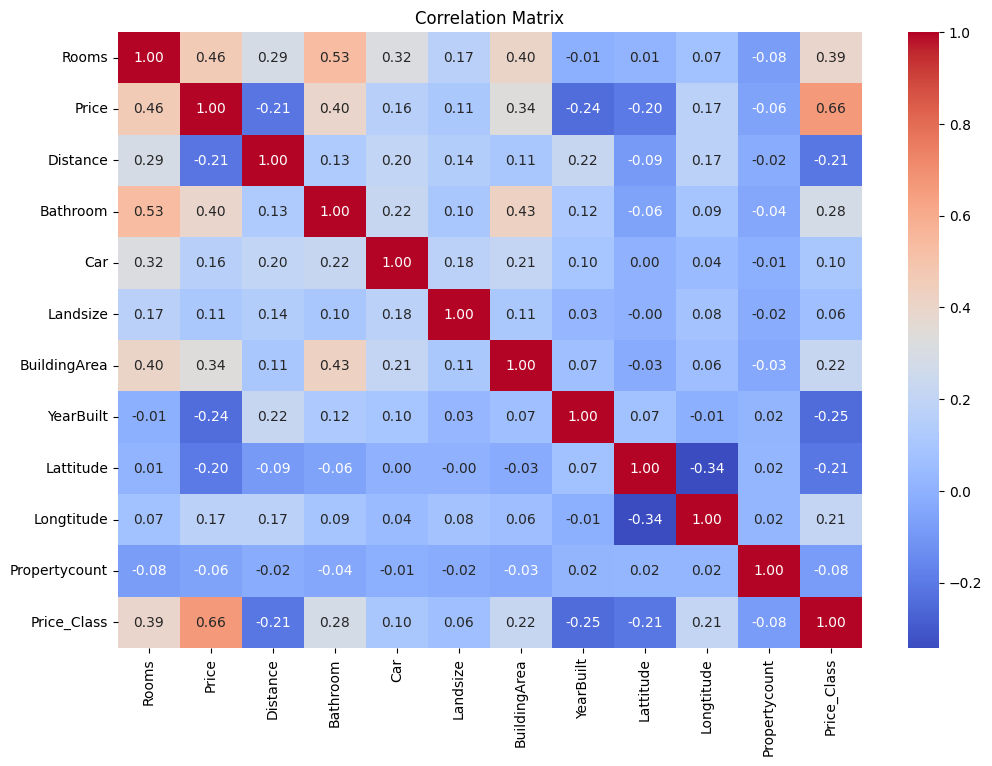

In [10]:
# Correlation Matrix

plt.figure(figsize=(12, 8))

corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

# Bab 3: Pra-Pemrosesan Data (Data Preprocessing)

Tahap pra-pemrosesan data adalah kunci keberhasilan model. Pada sel di bawah ini, kita melakukan serangkaian pembersihan data terstruktur:
1. **Menghapus Baris Kosong pada Target**: Properti tanpa informasi `Price` dihapus karena harga adalah target klasifikasi.
2. **Seleksi Fitur (Feature Selection)**: Membuang kolom yang tidak relevan (seperti `Address`, `SellerG`, `Date`, `Suburb`, `Postcode`, `CouncilArea`) serta kolom redundan (`Bedroom2` karena sudah diwakili oleh `Rooms`).
3. **Imputasi Nilai Kosong (Imputation)**: Mengisi data numerik yang kosong dengan nilai **Median** masing-masing kolom untuk menjaga integritas data tanpa bias.
4. **Pembersihan Outlier Selektif (Selective Outlier Removal)**:
   - Membatasi `YearBuilt` antara tahun 1800 s.d. 2026 (menghapus data typo bernilai tahun 1196).
   - Membatasi jumlah kamar `Rooms` maksimal 8 kamar dan kamar mandi `Bathroom` maksimal 6.
   - Membatasi `Landsize` maksimal 10.000 m² dan `BuildingArea` maksimal 1.000 m² untuk mengeliminasi kesalahan input ekstrem.
5. **One-Hot Encoding**: Mengubah kolom kategorikal (`Type`, `Method`, `Regionname`) menjadi kolom numerik biner (dummy variables).
6. **Membuat Target Klasifikasi**: Menghitung **Median Harga** dinamis (yang membagi seimbang data 50/50), lalu menetapkan kelas target `Price_Class` (0 untuk *Standard* di bawah median, 1 untuk *Premium* di atas/sama dengan median).
7. **Pemisahan Fitur & Target**: Memisahkan data menjadi matriks fitur `X_features` dan vektor target `y_target`.


In [4]:
# 2. DATA PREPARATION

# A. Menghapus baris yang tidak memiliki Harga (Price)
df = df[df['Price'].notna()].copy()

# B. Membuang kolom yang tidak relevan + Bedroom2 (redundan)
kolom_dibuang = ['Address', 'SellerG', 'Date', 'Suburb', 'Postcode', 'CouncilArea', 'Bedroom2']
df = df.drop(columns=kolom_dibuang)

# C. Penanganan Missing Values (Imputasi)
kolom_imputasi = ['Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
for col in kolom_imputasi:
    df[col] = df[col].fillna(df[col].median())

# D. Penanganan Outlier Selektif (Menghapus Data Tidak Wajar / Typo Ekstrem)
# 1. YearBuilt: Melbourne berdiri 1835. Kita hapus data sebelum 1800 atau setelah 2026
df = df[(df['YearBuilt'] >= 1800) & (df['YearBuilt'] <= 2026)]

# 2. Rooms & Bathroom ekstrem:
df = df[df['Rooms'] <= 8]
df = df[df['Bathroom'] <= 6]

# 3. Landsize & BuildingArea ekstrem (data error / typo):
df = df[df['Landsize'] <= 10000]
df = df[df['BuildingArea'] <= 1000]

# E. One Hot Encoding (karena tidak ada tingkatan)
df = pd.get_dummies(df, columns=['Type', 'Method', 'Regionname'], drop_first=True)

# F. Membuat Target Klasifikasi
median_price = df['Price'].median()
df['Price_Class'] = (df['Price'] >= median_price).astype(int)

# G. Menyiapkan fitur dan target
X_features = df.drop(columns=['Price', 'Price_Class'])
y_target = df['Price_Class']

print("Data Preparation Selesai.")


Data Preparation Selesai.


# Bab 4: Unsupervised Learning (K-Means Clustering)

Pada bab ini, kita mengelompokkan data properti secara *unsupervised* untuk melihat segmentasi pasar yang terbentuk secara alami tanpa label eksternal.

### Langkah-langkah:
1. **Standardisasi Skala**: Menggunakan `StandardScaler` agar perbedaan satuan tidak mengacaukan perhitungan jarak Euclidean pada K-Means.
2. **Elbow Method**: Menguji nilai K dari 1 s.d. 9 untuk melihat penurunan nilai *Inertia* (variansi dalam klaster). Titik siku (Elbow) terbaik terpilih pada **K=3**.
3. **Pemodelan K-Means**: Melatih model dengan K=3, lalu menambahkan label `Cluster` ke dataset.
4. **Karakteristik Segmen**: Menghitung harga rata-rata, jarak CBD, dan jumlah kamar di tiap klaster untuk memprofilkan segmen:
   - **Cluster 0**: Suburban Barat (Menengah & Ekonomis).
   - **Cluster 1**: Elite / Urban (Premium & Mahal).
   - **Cluster 2**: Suburban Utara (Kompak & Dekat Kota).


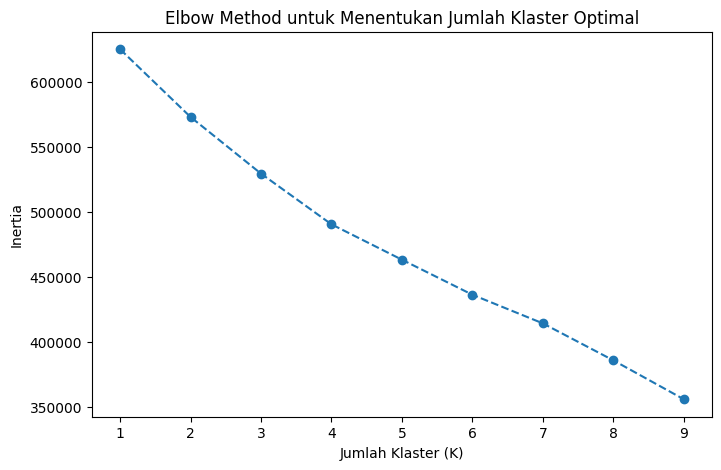


Karakteristik Klaster (Rata-rata per fitur):
            Rooms   Distance         Price  BuildingArea
Cluster                                                 
0        3.088463  11.776927  8.252408e+05    140.662363
1        3.054856  12.210738  1.263682e+06    144.117090
2        2.801629   9.292060  8.608054e+05    131.877553


In [5]:
# Scaling sebelum K-Means (unsupervised clustering)
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X_features)

# 3. K-MEANS CLUSTERING (UNSUPERVISED)

# Mencari jumlah klaster optimal dengan Elbow Method
inertias = []
K_range = range(1, 10)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia')
plt.show()

# Berdasarkan Elbow, asumsikan K=3 adalah yang paling optimal
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Menampilkan rata-rata karakteristik dari setiap klaster
print("\nKarakteristik Klaster (Rata-rata per fitur):")
cluster_summary = df.groupby('Cluster')[['Rooms', 'Distance', 'Price', 'BuildingArea']].mean()
print(cluster_summary)

# Bab 5: Supervised Learning (Klasifikasi Kelas Harga)

Pada bab ini, kita membangun model klasifikasi untuk memprediksi apakah suatu properti masuk ke kelas harga **Standard** atau **Premium** berdasarkan spesifikasi fisiknya dengan pembagi harga median.

### Langkah-langkah Pemodelan:
1. **Pemisahan Latih-Uji (Train-Test Split)**: Membagi data dengan rasio 80% untuk data latih dan 20% untuk data uji guna memvalidasi performa model secara objektif.
2. **Normalisasi Fitur**: Menstandarisasikan skala fitur pada data latih dan data uji secara terpisah untuk mencegah kebocoran data (*data leakage*).
3. **Pelatihan Model Awal (Base Model)**:
   - **Logistic Regression**: Model linier klasifikasi peluang.
   - **Naive Bayes Classifier**: Model probabilitas berbasis teorema Bayes.
4. **Evaluasi Awal**: Menampilkan nilai Akurasi, Laporan Klasifikasi (Precision, Recall, F1-Score), serta visualisasi Confusion Matrix untuk model Logistic Regression awal.


=== LOGISTIC REGRESSION ===
Akurasi: 0.8531
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2682
           1       0.86      0.85      0.85      2756

    accuracy                           0.85      5438
   macro avg       0.85      0.85      0.85      5438
weighted avg       0.85      0.85      0.85      5438



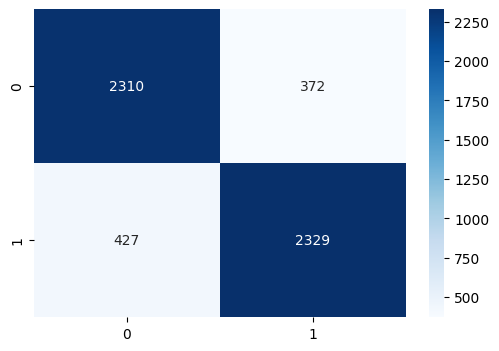


=== NAIVE BAYES CLASSIFIER ===
Akurasi: 0.7394
              precision    recall  f1-score   support

           0       0.88      0.55      0.67      2682
           1       0.68      0.93      0.78      2756

    accuracy                           0.74      5438
   macro avg       0.78      0.74      0.73      5438
weighted avg       0.78      0.74      0.73      5438



In [6]:
# 4. SUPERVISED LEARNING (KLASIFIKASI)

# Membagi data terlebih dahulu
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=42
)

# Scaling setelah split data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# A. LOGISTIC REGRESSION
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_logreg):.4f}")
print(classification_report(y_test, y_pred_logreg))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot=True, fmt='d', cmap='Blues')
plt.show()

# B. NAIVE BAYES
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_scaled, y_train)
y_pred_nb = nb_classifier.predict(X_test_scaled)

print("\n=== NAIVE BAYES CLASSIFIER ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))


## 5.1 Evaluasi Kurva ROC & Nilai AUC
Kurva ROC (Receiver Operating Characteristic) dan skor AUC (Area Under Curve) digunakan untuk mengukur kemampuan diskriminasi model Logistic Regression dalam membedakan kelas Standard dan Premium pada berbagai threshold keputusan. Nilai AUC berkisar dari 0.5 (tebakan acak) hingga 1.0 (klasifikasi sempurna).


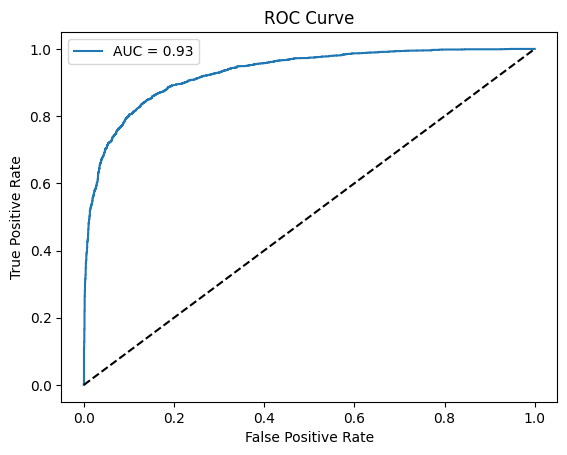

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# Hitung probabilitas untuk LogReg
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Bab 6: Optimasi Model (Hyperparameter Tuning)

Untuk mendapatkan performa model terbaik, kita melakukan optimasi parameter (tuning) menggunakan metode **GridSearchCV** dengan validasi silang 5-Fold (5-Fold Cross-Validation).
- **Logistic Regression Tuning**: Menguji kombinasi parameter regulasi `C` dan jenis pinalti (`l1` dengan solver `liblinear`, serta `l2` dengan solver `lbfgs`).
- **Naive Bayes Tuning**: Menguji nilai `var_smoothing` untuk menghaluskan kurva distribusi probabilitas kelas.


In [11]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Hyperparameter Tuning

# A. Logistic Regression Tuning (Expanded Grid)
param_grid_lr = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs'], 'max_iter': [1000]}
]

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_lr.fit(X_train_scaled, y_train)

print("=== LOGISTIC REGRESSION TUNING ===")
print("Best Parameters:", grid_search_lr.best_params_)
print("Best CV Score   :", grid_search_lr.best_score_)

# B. Naive Bayes Tuning
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_nb.fit(X_train_scaled, y_train)

print("\n=== NAIVE BAYES TUNING ===")
print("Best Parameters:", grid_search_nb.best_params_)
print("Best CV Score   :", grid_search_nb.best_score_)


=== LOGISTIC REGRESSION TUNING ===
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score   : 0.8595466229192918

=== NAIVE BAYES TUNING ===
Best Parameters: {'var_smoothing': np.float64(0.1)}
Best CV Score   : 0.7365640663924531


## 6.1 Evaluasi Performa Model Hasil Tuning
Di bawah ini kita melatih kembali model terbaik (*best estimator*) hasil pencarian Grid Search pada data latih dan mengevaluasi akurasinya menggunakan data uji.


In [12]:
best_logreg = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_logreg.predict(X_test_scaled)

best_nb = grid_search_nb.best_estimator_
y_pred_nb_tuned = best_nb.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION (TUNED) ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(classification_report(y_test, y_pred_lr_tuned))

print("\n=== NAIVE BAYES (TUNED) ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_nb_tuned):.4f}")
print(classification_report(y_test, y_pred_nb_tuned))


=== LOGISTIC REGRESSION (TUNED) ===
Akurasi: 0.8531
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2682
           1       0.86      0.85      0.85      2756

    accuracy                           0.85      5438
   macro avg       0.85      0.85      0.85      5438
weighted avg       0.85      0.85      0.85      5438


=== NAIVE BAYES (TUNED) ===
Akurasi: 0.7451
              precision    recall  f1-score   support

           0       0.89      0.55      0.68      2682
           1       0.68      0.93      0.79      2756

    accuracy                           0.75      5438
   macro avg       0.78      0.74      0.73      5438
weighted avg       0.78      0.75      0.74      5438



## 6.2 Confusion Matrix Model Logistic Regression Tuned
Grafik di bawah menggambarkan Confusion Matrix untuk model Logistic Regression terbaik hasil tuning (Akurasi 85.31%). Confusion Matrix menunjukkan jumlah prediksi yang benar (True Positive dan True Negative) serta kesalahan model (False Positive dan False Negative).


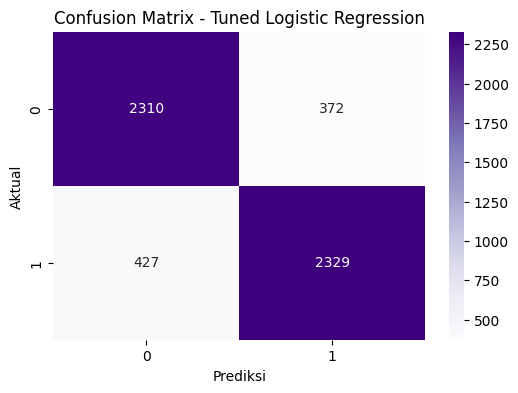

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr_tuned),
    annot=True,
    fmt='d',
    cmap='Purples'
)
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


## 6.3 Ringkasan Perbandingan Akurasi Model
Perbandingan akhir antara model awal (base models) dan model yang telah dioptimalkan (tuned models) untuk Logistic Regression dan Naive Bayes. Model Logistic Regression Tuned dipilih sebagai model keputusan utama untuk dashboard karena akurasinya yang paling tinggi.


In [14]:
print("Akurasi Logistic Regression Awal  :", accuracy_score(y_test, y_pred_logreg))
print("Akurasi Logistic Regression Tuned :", accuracy_score(y_test, y_pred_lr_tuned))
print("Akurasi Naive Bayes Awal          :", accuracy_score(y_test, y_pred_nb))
print("Akurasi Naive Bayes Tuned         :", accuracy_score(y_test, y_pred_nb_tuned))


Akurasi Logistic Regression Awal  : 0.8530709819786686
Akurasi Logistic Regression Tuned : 0.8530709819786686
Akurasi Naive Bayes Awal          : 0.7394262596542847
Akurasi Naive Bayes Tuned         : 0.7451268848841486


## 6.4 Serialisasi Model & Ekspor Berkas (Joblib Export)

Setelah mengevaluasi model terbaik, kita siap melakukan deployment. Untuk memisahkan proses pelatihan model (training) di notebook dengan proses pemakaian model (inference) di dashboard, kita mengekspor seluruh model yang telah dilatih (`best_logreg`, `best_nb`, `kmeans`), scalers (`scaler`, `scaler_kmeans`), serta nama fitur dan batas median harga menggunakan pustaka **Joblib**.

Ini akan mempercepat pemuatan dashboard secara signifikan karena dashboard cukup memuat berkas biner `.joblib` hasil latih tanpa perlu melakukan pemrosesan data dan pelatihan ulang dari nol.


In [ ]:
import joblib

# Menyimpan seluruh artefak model ke satu berkas joblib untuk dideploy di dashboard
artifacts = {
    'kmeans': kmeans,
    'scaler_kmeans': scaler_kmeans,
    'logreg': best_logreg,
    'nb': best_nb,
    'scaler': scaler,
    'median_val': median_price,
    'feature_names': list(X_features.columns)
}

joblib.dump(artifacts, 'ml_artifacts.joblib')
print("Seluruh artefak model berhasil diekspor ke berkas 'ml_artifacts.joblib'!")


# Bab 7: Implementasi Dashboard Streamlit Interaktif

Sel di bawah ini menggunakan perintah magis Jupyter `%%writefile dashboard.py` untuk menulis seluruh kode aplikasi web Streamlit interaktif secara otomatis. Dashboard ini mengintegrasikan model pre-trained hasil serialisasi, visualisasi peta sebaran spasial, analisis klaster dinamis berdasarkan kamar, serta kalkulator finansial khusus peran pengguna.


In [15]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# Page configurations
st.set_page_config(
    page_title="Melbourne Housing Market Analytics",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Initialize session state for user role if not present
if 'user_role' not in st.session_state:
    st.session_state['user_role'] = "Calon Pembeli Properti (Home Buyer)"

# App Custom CSS for premium theme-aware styling
st.markdown("""
    <style>
    .stApp {
        background-color: var(--background-color);
        color: var(--text-color);
        font-family: 'Outfit', 'Inter', 'Segoe UI', sans-serif;
    }
    /* Title container styling */
    .title-container {
        background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);
        padding: 35px;
        border-radius: 15px;
        color: #ffffff !important;
        margin-bottom: 25px;
        box-shadow: 0 8px 20px rgba(30,60,114,0.15);
    }
    .title-container h1 {
        color: #ffffff !important;
        margin: 0;
        font-weight: 700;
        font-size: 2.2rem;
    }
    .title-container p {
        color: #e2e8f0 !important;
        margin: 8px 0 0 0;
        font-size: 1.1rem;
    }
    /* Metric Card styling - theme aware */
    .metric-card {
        background-color: var(--secondary-background-color);
        color: var(--text-color) !important;
        padding: 22px;
        border-radius: 12px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        text-align: center;
        border: 1px solid rgba(128, 128, 128, 0.2);
        transition: transform 0.2s ease, box-shadow 0.2s ease;
        margin-bottom: 20px;
    }
    .metric-card:hover {
        transform: translateY(-3px);
        box-shadow: 0 6px 20px rgba(0,0,0,0.08);
    }
    .metric-value {
        font-size: 1.8rem;
        font-weight: 800;
        color: #2563eb;
        margin: 4px 0;
    }
    .metric-label {
        font-size: 0.85rem;
        color: var(--text-color);
        opacity: 0.8;
        font-weight: 600;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }
    .metric-muted {
        font-size: 0.75rem;
        color: var(--text-color);
        opacity: 0.6;
        margin-top: 4px;
    }
    /* Persona Card styling */
    .persona-box {
        background-color: var(--secondary-background-color);
        border-left: 5px solid #2563eb;
        color: var(--text-color) !important;
        padding: 20px;
        border-radius: 0 10px 10px 0;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        margin-bottom: 20px;
    }
    .persona-title {
        font-size: 1.25rem;
        font-weight: 700;
        color: #2563eb;
        margin-bottom: 10px;
    }
    .persona-box p, .persona-box ul, .persona-box li {
        color: var(--text-color) !important;
    }
    /* Info Box */
    .info-box {
        background-color: var(--secondary-background-color);
        border: 1px solid rgba(128, 128, 128, 0.2);
        color: var(--text-color) !important;
        padding: 15px;
        border-radius: 8px;
        margin-top: 10px;
        font-size: 0.9rem;
    }
    /* Prediction cards */
    .result-card-premium {
        background-color: rgba(239, 68, 68, 0.1);
        border: 2px solid rgba(239, 68, 68, 0.3);
        color: var(--text-color) !important;
        padding: 25px;
        border-radius: 12px;
        box-shadow: 0 4px 15px rgba(239, 68, 68, 0.05);
        margin-bottom: 20px;
    }
    .result-card-premium h3 {
        color: #ef4444 !important;
        margin-top: 0;
    }
    .result-card-standard {
        background-color: rgba(34, 197, 94, 0.1);
        border: 2px solid rgba(34, 197, 94, 0.3);
        color: var(--text-color) !important;
        padding: 25px;
        border-radius: 12px;
        box-shadow: 0 4px 15px rgba(34, 197, 94, 0.05);
        margin-bottom: 20px;
    }
    .result-card-standard h3 {
        color: #22c55e !important;
        margin-top: 0;
    }
    </style>
""", unsafe_allow_html=True)

# Data Preprocessing Cache
@st.cache_data
def load_and_preprocess_data():
    df_raw = pd.read_csv('Melbourne_Data.csv')
    
    # 1. Clean missing Price and Regionname (to prevent sort type errors with NaN values)
    df = df_raw[df_raw['Price'].notna() & df_raw['Regionname'].notna()].copy()
    
    # 2. Drop redundant and irrelevant columns
    kolom_dibuang = ['Address', 'SellerG', 'Date', 'Suburb', 'Postcode', 'CouncilArea', 'Bedroom2']
    df = df.drop(columns=kolom_dibuang)
    
    # 3. Impute remaining missing values
    kolom_imputasi = ['Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
    for col in kolom_imputasi:
        df[col] = df[col].fillna(df[col].median())
        
    # 4. Selective Outlier Removal
    df = df[(df['YearBuilt'] >= 1800) & (df['YearBuilt'] <= 2026)]
    df = df[df['Rooms'] <= 8]
    df = df[df['Bathroom'] <= 6]
    df = df[df['Landsize'] <= 10000]
    df = df[df['BuildingArea'] <= 1000]
    
    df_clean = df.copy()
    
    # 5. One Hot Encoding
    df_encoded = pd.get_dummies(df, columns=['Type', 'Method', 'Regionname'], drop_first=True)
    
    # 6. Classification Target (Standard vs Premium)
    median_price = df_encoded['Price'].median()
    df_encoded['Price_Class'] = (df_encoded['Price'] >= median_price).astype(int)
    
    return df_raw, df_clean, df_encoded, median_price

# Model Loading or Fallback Training Cache
@st.cache_resource
def load_or_train_models(df_encoded):
    import joblib
    import os
    
    artifact_file = 'ml_artifacts.joblib'
    X_features = df_encoded.drop(columns=['Price', 'Price_Class'])
    y_target = df_encoded['Price_Class']
    feature_names = list(X_features.columns)
    
    # Try to load pre-trained artifacts first
    if os.path.exists(artifact_file):
        try:
            artifacts = joblib.load(artifact_file)
            st.sidebar.success("✅ Model dimuat via Joblib (Pre-trained)!")
            
            kmeans = artifacts['kmeans']
            scaler_kmeans = artifacts['scaler_kmeans']
            logreg = artifacts['logreg']
            nb = artifacts['nb']
            scaler = artifacts['scaler']
            median_val_loaded = artifacts['median_val']
            feature_names_loaded = artifacts['feature_names']
            
            # Predict clusters for df_clean
            X_scaled_kmeans = scaler_kmeans.transform(X_features)
            clusters = kmeans.predict(X_scaled_kmeans)
            
            # Evaluate test accuracy
            X_train, X_test, y_train, y_test = train_test_split(
                X_features, y_target, test_size=0.2, random_state=42
            )
            X_test_scaled = scaler.transform(X_test)
            acc_lr = accuracy_score(y_test, logreg.predict(X_test_scaled))
            acc_nb = accuracy_score(y_test, nb.predict(X_test_scaled))
            
            return kmeans, scaler_kmeans, clusters, logreg, nb, scaler, feature_names_loaded, acc_lr, acc_nb
            
        except Exception as e:
            st.sidebar.warning(f"⚠️ Gagal memuat model: {e}. Fallback latih otomatis aktif.")
            
    # Fallback: Train models on the fly if pre-trained file not found or load fails
    st.sidebar.info("ℹ️ Menjalankan pelatihan model otomatis (Fallback)...")
    
    scaler_kmeans = StandardScaler()
    X_scaled_kmeans = scaler_kmeans.fit_transform(X_features)
    
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled_kmeans)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_target, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    logreg = LogisticRegression(C=1, penalty='l1', solver='liblinear', random_state=42)
    logreg.fit(X_train_scaled, y_train)
    acc_lr = accuracy_score(y_test, logreg.predict(X_test_scaled))
    
    nb = GaussianNB(var_smoothing=0.1)
    nb.fit(X_train_scaled, y_train)
    acc_nb = accuracy_score(y_test, nb.predict(X_test_scaled))
    
    return kmeans, scaler_kmeans, clusters, logreg, nb, scaler, feature_names, acc_lr, acc_nb

# Load and train
df_raw, df_clean, df_encoded, median_val = load_and_preprocess_data()
kmeans, scaler_kmeans, clusters, logreg, nb, scaler, feature_names, acc_lr, acc_nb = load_or_train_models(df_encoded)

# Add cluster labels and Price_Class to clean dataframe for EDA
df_clean['Cluster'] = clusters
df_clean['Price_Class'] = (df_clean['Price'] >= median_val).astype(int)

# Sidebar Navigation
st.sidebar.image("https://upload.wikimedia.org/wikipedia/commons/e/e5/Telkom_University_Logo.svg", width=150)
st.sidebar.title("Melbourne Housing Portal")
st.sidebar.write("Kelompok 4 - Penambangan Data")
st.sidebar.markdown("---")

menu = st.sidebar.radio(
    "PILIH HALAMAN (PAGE):",
    [
        "👋 Beranda & Panduan", 
        "📊 Eksplorasi Pasar (EDA)", 
        "🔍 K-Means Clustering", 
        "🤖 Prediksi Kelas Harga", 
        "⚙️ Proses & Hasil Data Mining",
        "📋 Tentang & Metodologi"
    ]
)

# Persona Sidebar Banner (Active Role Tracker)
role_short = "Pembeli" if "Pembeli" in st.session_state['user_role'] else ("Agen" if "Agen" in st.session_state['user_role'] else "Investor")
role_tip = ""
if role_short == "Pembeli":
    role_tip = "Fokus Anda: Keterjangkauan harga dan kesesuaian wilayah tinggal."
elif role_short == "Agen":
    role_tip = "Fokus Anda: Penilaian harga listing klien dan tren penjualan wilayah."
else:
    role_tip = "Fokus Anda: Potensi yield sewa dan area capital growth tinggi."

st.sidebar.markdown(f"""
    <div style="background-color: rgba(37, 99, 235, 0.15); border-left: 4px solid #2563eb; padding: 10px; border-radius: 4px; font-size: 0.85rem; color: var(--text-color); margin-top: 10px; margin-bottom: 15px;">
        <b>👤 Peran Aktif:</b><br>{st.session_state['user_role']}<br>
        <span style="font-size:0.75rem; opacity:0.8;"><i>{role_tip}</i></span>
    </div>
""", unsafe_allow_html=True)

# Feature label mapper for local model explanation
feature_labels = {
    'Rooms': 'Jumlah Kamar (Rooms)',
    'Distance': 'Jarak ke CBD (Distance)',
    'Bathroom': 'Jumlah Kamar Mandi (Bathroom)',
    'Car': 'Kapasitas Parkir (Car)',
    'Landsize': 'Luas Lahan (Landsize)',
    'BuildingArea': 'Luas Bangunan (BuildingArea)',
    'YearBuilt': 'Tahun Pembangunan (YearBuilt)',
    'Type_t': 'Tipe Properti: Townhouse',
    'Type_u': 'Tipe Properti: Unit/Apartemen',
    'Regionname_Eastern Metropolitan': 'Wilayah: Eastern Metropolitan',
    'Regionname_Eastern Victoria': 'Wilayah: Eastern Victoria',
    'Regionname_Northern Metropolitan': 'Wilayah: Northern Metropolitan',
    'Regionname_Northern Victoria': 'Wilayah: Northern Victoria',
    'Regionname_South-Eastern Metropolitan': 'Wilayah: South-Eastern Metropolitan',
    'Regionname_Southern Metropolitan': 'Wilayah: Southern Metropolitan',
    'Regionname_Western Metropolitan': 'Wilayah: Western Metropolitan',
    'Regionname_Western Victoria': 'Wilayah: Western Victoria',
    'Method_S': 'Metode Penjualan: Terjual (S)',
    'Method_SA': 'Metode Penjualan: Terjual Sebelum Lelang (SA)',
    'Method_SN': 'Metode Penjualan: Terjual Setelah Lelang (SN)',
    'Method_SP': 'Metode Penjualan: Lolos Lelang (SP)',
    'Propertycount': 'Jumlah Properti di Suburb',
    'Lattitude': 'Koordinat Lintang (Lattitude)',
    'Longtitude': 'Koordinat Bujur (Longtitude)'
}

# 1. PAGE: WELCOME & USER GUIDE
if menu == "👋 Beranda & Panduan":
    st.markdown("""
        <div class="title-container">
            <h1>🏠 Melbourne Housing Market Analytics</h1>
            <p>Portal Analitik & Estimasi Kelas Harga Properti Melbourne - Berbasis Data Mining</p>
        </div>
    """, unsafe_allow_html=True)
    
    st.markdown("""
        ### Selamat Datang di Portal Analisis Data Mining
        Aplikasi interaktif ini dirancang untuk menyajikan hasil analisis data dari **Melbourne Housing Market** secara ramah pengguna (user-friendly). Kami menggabungkan pendekatan **Unsupervised Learning (K-Means Clustering)** dan **Supervised Learning (Logistic Regression & Naive Bayes Classifier)** ke dalam alat bantu keputusan praktis.
        
        Agar Anda dapat memanfaatkan dashboard ini secara maksimal, kami telah menyediakan **Sistem Peran (Role-Based Features)**. Silakan ikuti panduan di bawah untuk mulai menggunakan dashboard.
        
        ---
    """)
    
    # 1. VISUAL USER JOURNEY
    st.markdown("### 🗺️ Peta Navigasi Pengguna (Bagaimana Cara Memulainya?)")
    st.markdown("""
        <div style="background-color: var(--secondary-background-color); border: 1px solid rgba(128,128,128,0.2); padding: 20px; border-radius: 12px; margin-bottom: 25px; color: var(--text-color);">
            <div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: space-between;">
                <div style="flex: 1; min-width: 200px; background-color: rgba(37, 99, 235, 0.08); border-left: 4px solid #2563eb; padding: 15px; border-radius: 4px;">
                    <h5 style="margin-top:0; color:#2563eb; font-weight:bold;">📍 Langkah 1</h5>
                    <p style="font-size:0.85rem; margin-bottom:0; line-height: 1.4;"><b>Pilih Peran Anda</b> di halaman ini untuk menyesuaikan jenis kalkulator finansial dan tabel analisis yang akan diaktifkan.</p>
                </div>
                <div style="flex: 1; min-width: 200px; background-color: rgba(16, 185, 129, 0.08); border-left: 4px solid #10b981; padding: 15px; border-radius: 4px;">
                    <h5 style="margin-top:0; color:#10b981; font-weight:bold;">📍 Langkah 2</h5>
                    <p style="font-size:0.85rem; margin-bottom:0; line-height: 1.4;">Buka halaman <b>📊 Eksplorasi Pasar (EDA)</b>. Pelajari tren harga umum, sebaran lokasi peta, dan tabel wilayah khusus peran Anda.</p>
                </div>
                <div style="flex: 1; min-width: 200px; background-color: rgba(245, 158, 11, 0.08); border-left: 4px solid #f59e0b; padding: 15px; border-radius: 4px;">
                    <h5 style="margin-top:0; color:#f59e0b; font-weight:bold;">📍 Langkah 3</h5>
                    <p style="font-size:0.85rem; margin-bottom:0; line-height: 1.4;">Buka halaman <b>🔍 K-Means Clustering</b>. Masukkan anggaran dan jumlah kamar untuk mencari klaster wilayah yang paling cocok.</p>
                </div>
                <div style="flex: 1; min-width: 200px; background-color: rgba(239, 68, 68, 0.08); border-left: 4px solid #ef4444; padding: 15px; border-radius: 4px;">
                    <h5 style="margin-top:0; color:#ef4444; font-weight:bold;">📍 Langkah 4</h5>
                    <p style="font-size:0.85rem; margin-bottom:0; line-height: 1.4;">Buka halaman <b>🤖 Prediksi Kelas Harga</b>. Masukkan spesifikasi rumah untuk mengestimasi kelas harga & KPR/ROI secara real-time.</p>
                </div>
            </div>
        </div>
    """, unsafe_allow_html=True)
    
    # 2. ROLE MATRIX TABLE
    st.markdown("### 👤 Apa Bedanya Antar Peran?")
    st.write("Sistem akan menyesuaikan tabel analisis di halaman EDA dan membuka kalkulator interaktif khusus di halaman Prediksi sesuai peran:")
    
    st.markdown(f"""
        <table style="width:100%; border-collapse: collapse; margin-bottom: 25px; color: var(--text-color); font-size: 0.9rem; border: 1px solid rgba(128,128,128,0.2);">
            <thead>
                <tr style="border-bottom: 2px solid rgba(128,128,128,0.4); text-align: left; background-color: rgba(128,128,128,0.05);">
                    <th style="padding: 12px; font-weight: bold; border-right: 1px solid rgba(128,128,128,0.2);">Fitur / Halaman</th>
                    <th style="padding: 12px; color: #2563eb; font-weight: bold; border-right: 1px solid rgba(128,128,128,0.2);">🏠 Calon Pembeli (Buyer)</th>
                    <th style="padding: 12px; color: #10b981; font-weight: bold; border-right: 1px solid rgba(128,128,128,0.2);">💼 Agen Properti (Agent)</th>
                    <th style="padding: 12px; color: #f59e0b; font-weight: bold;">📈 Investor Properti (Investor)</th>
                </tr>
            </thead>
            <tbody>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2);">
                    <td style="padding: 12px; font-weight: bold; border-right: 1px solid rgba(128,128,128,0.2);">Fokus Utama</td>
                    <td style="padding: 12px; border-right: 1px solid rgba(128,128,128,0.2);">Keterjangkauan harga rumah tinggal & kesesuaian wilayah.</td>
                    <td style="padding: 12px; border-right: 1px solid rgba(128,128,128,0.2);">Menentukan harga listing klien & memaksimalkan peluang terjual.</td>
                    <td style="padding: 12px;">Keuntungan sewa (rental yield) & pertumbuhan modal aset (ROI).</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2); background-color: rgba(128,128,128,0.02);">
                    <td style="padding: 12px; font-weight: bold; border-right: 1px solid rgba(128,128,128,0.2);">Tabel Khusus EDA</td>
                    <td style="padding: 12px; border-right: 1px solid rgba(128,128,128,0.2);"><b>Wilayah Paling Ekonomis:</b> Wilayah diurutkan dari harga rata-rata terendah.</td>
                    <td style="padding: 12px; border-right: 1px solid rgba(128,128,128,0.2);"><b>Volume Listing Teraktif:</b> Wilayah dengan volume transaksi terpadat.</td>
                    <td style="padding: 12px;"><b>Rasio Premium:</b> Wilayah dengan persentase rumah Premium tertinggi.</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2);">
                    <td style="padding: 12px; font-weight: bold; border-right: 1px solid rgba(128,128,128,0.2);">Kalkulator Prediksi</td>
                    <td style="padding: 12px; border-right: 1px solid rgba(128,128,128,0.2);"><b>Simulasi KPR:</b> Hitung cicilan KPR bulanan & kelayakan anggaran pendapatan.</td>
                    <td style="padding: 12px; border-right: 1px solid rgba(128,128,128,0.2);"><b>Komisi & Iklan:</b> Hitung komisi bersih agen & buat draf brosur iklan otomatis.</td>
                    <td style="padding: 12px;"><b>Yield & ROI:</b> Estimasi yield sewa mingguan & proyeksi laba modal 5 tahun.</td>
                </tr>
            </tbody>
        </table>
    """, unsafe_allow_html=True)
    
    # Persona Selector
    st.markdown("### 👤 Pilih Peran / Persona Anda:")
    persona = st.selectbox(
        "Pilih peran Anda untuk mendapatkan panduan navigasi yang dipersonalisasi:",
        ["Calon Pembeli Properti (Home Buyer)", "Agen Real Estat (Real Estate Agent)", "Investor Properti (Property Investor)"],
        index=["Calon Pembeli Properti (Home Buyer)", "Agen Real Estat (Real Estate Agent)", "Investor Properti (Property Investor)"].index(st.session_state['user_role'])
    )
    # Sync selector back to session_state
    if persona != st.session_state['user_role']:
        st.session_state['user_role'] = persona
        st.rerun()
    
    if persona == "Calon Pembeli Properti (Home Buyer)":
        st.markdown("""
            <div class="persona-box">
                <div class="persona-title">🏠 Panduan Langkah untuk Calon Pembeli Properti (Home Buyer)</div>
                <p><b>Tujuan Utama:</b> Mencari hunian ideal yang ramah anggaran, memahami wilayah termurah, dan memastikan tidak overpay.</p>
                <ul>
                    <li><b>Langkah 1:</b> Masuk ke halaman <b>📊 Eksplorasi Pasar (EDA)</b>. Cek histogram harga untuk melihat harga pasaran, lalu scroll ke bawah untuk melihat <b>Tabel Wilayah Paling Ekonomis</b> (untuk memilah wilayah termurah).</li>
                    <li><b>Langkah 2:</b> Masuk ke halaman <b>🔍 K-Means Clustering</b>. Masukkan budget maksimal dan jumlah kamar minimum Anda pada <b>Cluster Finder</b> untuk menemukan klaster wilayah yang ramah anggaran (contoh: Cluster 0 atau 2).</li>
                    <li><b>Langkah 3:</b> Masuk ke halaman <b>🤖 Prediksi Kelas Harga</b>. Geser spesifikasi rumah incaran Anda. Model secara real-time akan memprediksi apakah harganya masuk kelas Standard/Premium. Isi <b>Kalkulator KPR</b> di bawahnya untuk menguji apakah cicilannya aman dari batas 35% pendapatan bulanan Anda.</li>
                </ul>
            </div>
        """, unsafe_allow_html=True)
    elif persona == "Agen Real Estat (Real Estate Agent)":
        st.markdown("""
            <div class="persona-box">
                <div class="persona-title">💼 Panduan Langkah untuk Agen Real Estat (Real Estate Agent)</div>
                <p><b>Tujuan Utama:</b> Membantu klien menentukan nilai wajar listing rumah, menganalisis wilayah komisi terbesar, dan menyusun brosur penjualan.</p>
                <ul>
                    <li><b>Langkah 1:</b> Masuk ke halaman <b>📊 Eksplorasi Pasar (EDA)</b>. Scroll ke bawah untuk melihat <b>Tabel Volume Listing Teraktif</b> guna memetakan wilayah dengan perputaran transaksi properti terpadat.</li>
                    <li><b>Langkah 2:</b> Masuk ke halaman <b>🔍 K-Means Clustering</b>. Gunakan statistik rata-rata harga klaster untuk memberikan estimasi segmentasi wilayah listing klien Anda.</li>
                    <li><b>Langkah 3:</b> Masuk ke halaman <b>🤖 Prediksi Kelas Harga</b>. Masukkan spesifikasi properti klien Anda. Gunakan grafik <b>Faktor Pendorong Harga (Feature Contribution)</b> di bawahnya sebagai argumen ilmiah kepada klien mengenai keunggulan rumah mereka. Gunakan juga <b>Kalkulator Komisi</b> untuk melihat pendapatan komisi bersih Anda, serta salin <b>Brosur Deskripsi Otomatis</b> yang dibuat sistem untuk materi iklan promosi Anda.</li>
                </ul>
            </div>
        """, unsafe_allow_html=True)
    else:
        st.markdown("""
            <div class="persona-box">
                <div class="persona-title">📈 Panduan Langkah untuk Investor Properti (Property Investor)</div>
                <p><b>Tujuan Utama:</b> Menemukan aset undervalued, mengincar wilayah dengan capital growth tinggi, dan memproyeksikan rental yield.</p>
                <ul>
                    <li><b>Langkah 1:</b> Masuk ke halaman <b>📊 Eksplorasi Pasar (EDA)</b>. Pelajari matriks korelasi fitur di tab tren. Pindah ke tab Peta untuk melihat konsentrasi sebaran properti Premium, dan scroll ke bawah untuk melihat <b>Tabel Rasio Premium Wilayah</b>.</li>
                    <li><b>Langkah 2:</b> Masuk ke halaman <b>🔍 K-Means Clustering</b>. Pelajari karakteristik Cluster 1 (Elite/Urban) yang memiliki harga tinggi sebagai kandidat area dengan apresiasi nilai tanah terbaik jangka panjang.</li>
                    <li><b>Langkah 3:</b> Masuk ke halaman <b>🤖 Prediksi Kelas Harga</b>. Simulasikan parameter fisik properti. Scroll ke bawah untuk mengisi <b>Kalkulator Yield & ROI</b>. Model secara dinamis akan memproyeksikan persentase Rental Yield serta menggambar grafik <b>Proyeksi Nilai Properti Anda Selama 5 Tahun ke Depan</b> untuk menghitung ROI.</li>
                </ul>
            </div>
        """, unsafe_allow_html=True)
        
    st.success("🚀 **Siap Memulai?** Pilih peran Anda di atas, baca panduannya, lalu silakan gunakan menu navigasi di **Sidebar Sebelah Kiri** untuk mengeksplorasi halaman analitik!")

    # General Quick Stats Card
    st.markdown("### 📊 Ringkasan Singkat Data Melbourne Housing")
    
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Total Data Rumah</div>
                <div class="metric-value">{len(df_clean):,}</div>
                <div class="metric-muted">Setelah selective cleaning</div>
            </div>
        """, unsafe_allow_html=True)
    with col2:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Median Harga Pasar</div>
                <div class="metric-value">AUD {median_val:,.0f}</div>
                <div class="metric-muted">Batas Standard vs Premium</div>
            </div>
        """, unsafe_allow_html=True)
    with col3:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Harga Rata-Rata</div>
                <div class="metric-value">AUD {df_clean['Price'].mean():,.0f}</div>
                <div class="metric-muted">Distribusi skewness kanan</div>
            </div>
        """, unsafe_allow_html=True)
    with col4:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Akurasi Model Utama</div>
                <div class="metric-value">{acc_lr*100:.2f}%</div>
                <div class="metric-muted">Logistic Regression (Tuned)</div>
            </div>
        """, unsafe_allow_html=True)

# 2. PAGE: DESKRIPSI & EDA
elif menu == "📊 Eksplorasi Pasar (EDA)":
    st.markdown("""
        <div class="title-container">
            <h1>📊 Eksplorasi Pasar (EDA) Melbourne</h1>
            <p>Gunakan filter di sidebar sebelah kiri untuk menyaring data properti secara interaktif.</p>
        </div>
    """, unsafe_allow_html=True)
    
    # Persona specific tip banner on top
    if role_short == "Pembeli":
        st.success("💡 **Rekomendasi Pembeli:** Cermati grafik distribusi harga. Sebagian besar rumah di Melbourne berada di rentang ekonomis/menengah (di bawah AUD 1.2M), mewakili peluang bagus untuk memilah rumah bernilai stabil.")
    elif role_short == "Agen":
        st.info("💡 **Analisis Agen:** Matriks korelasi di bawah sangat berguna untuk berdiskusi dengan klien. Anda dapat menunjukkan secara ilmiah bahwa menambah jumlah kamar (Rooms, korelasi +0.50) memiliki dampak langsung paling besar pada harga jual properti.")
    else:
        st.warning("💡 **Insight Investor:** Tab **Sebaran Geografis** memetakan dengan jelas konsentrasi titik merah (Premium). Daerah Selatan dan Timur Melbourne terbukti merupakan magnet bagi properti berharga tinggi.")

    # Filter instructions in the sidebar
    st.sidebar.markdown("### 🛠️ Filter Eksplorasi Pasar")
    
    # Multiselects on sidebar
    # Tipe
    tipe_options = {
        "House / Cottage / Villa (h)": "h",
        "Duplex / Townhouse (t)": "t",
        "Unit / Apartment / Flat (u)": "u"
    }
    selected_type_names = st.sidebar.multiselect("Tipe Properti:", list(tipe_options.keys()), default=list(tipe_options.keys()))
    selected_types = [tipe_options[n] for n in selected_type_names]
    
    # Metode
    metode_options = ["S", "SP", "SA", "SN", "PI"]
    selected_methods = st.sidebar.multiselect("Metode Penjualan:", metode_options, default=metode_options)
    
    # Wilayah
    wilayah_options = sorted(list(df_clean['Regionname'].unique()))
    selected_regions = st.sidebar.multiselect("Wilayah Properti (Regionname):", wilayah_options, default=wilayah_options)
    
    # Filter DataFrame
    df_filtered = df_clean[
        (df_clean['Type'].isin(selected_types)) &
        (df_clean['Method'].isin(selected_methods)) &
        (df_clean['Regionname'].isin(selected_regions))
    ].copy()
    
    if df_filtered.empty:
        st.warning("⚠️ Tidak ada properti yang cocok dengan filter yang dipilih. Silakan ubah filter Anda di sidebar.")
    else:
        # Dynamic metrics
        m1, m2, m3, m4 = st.columns(4)
        with m1:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Properti Terfilter</div><div class="metric-value">{len(df_filtered):,}</div><div class="metric-muted">Dari total {len(df_clean):,}</div></div>', unsafe_allow_html=True)
        with m2:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Harga Rata-Rata</div><div class="metric-value">AUD {df_filtered["Price"].mean():,.0f}</div><div class="metric-muted">Median: AUD {df_filtered["Price"].median():,.0f}</div></div>', unsafe_allow_html=True)
        with m3:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Kamar Rata-Rata</div><div class="metric-value">{df_filtered["Rooms"].mean():.2f}</div><div class="metric-muted">Kamar Mandi: {df_filtered["Bathroom"].mean():.2f}</div></div>', unsafe_allow_html=True)
        with m4:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Jarak Rata-Rata ke CBD</div><div class="metric-value">{df_filtered["Distance"].mean():.2f} km</div><div class="metric-muted">Jangkauan terjauh: {df_filtered["Distance"].max():.1f} km</div></div>', unsafe_allow_html=True)
            
        # Tabs for layout
        tab_trends, tab_map = st.tabs(["📈 Tren & Distribusi Pasar", "🗺️ Sebaran Geografis"])
        
        with tab_trends:
            st.markdown("### Visualisasi Distribusi dan Korelasi Fitur")
            c1, c2 = st.columns(2)
            
            with c1:
                st.write("**Distribusi Harga Properti Melbourne (Terfilter)**")
                fig, ax = plt.subplots(figsize=(8, 5))
                sns.histplot(df_filtered['Price'], bins=50, kde=True, color='#1e3c72', ax=ax)
                ax.set_xlabel("Harga (AUD)")
                ax.set_ylabel("Frekuensi")
                st.pyplot(fig)
                st.markdown("""
                    <div class="info-box">
                        <b>Bagaimana Cara Membaca Grafik Ini?</b><br>
                        Grafik histogram ini memperlihatkan sebaran harga properti. Ekor grafik yang condong ke kanan (right-skewed) menunjukkan bahwa sebagian besar rumah berkisar di harga rata-rata menengah (AUD 600k - 1.2M), namun terdapat sebagian kecil rumah mewah bernilai sangat tinggi yang menarik ekor distribusi ke arah kanan.
                    </div>
                """, unsafe_allow_html=True)
                
            with c2:
                st.write("**Matriks Korelasi Fitur Numerik Utama**")
                fig, ax = plt.subplots(figsize=(8, 5))
                numeric_cols = ['Price', 'Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
                sns.heatmap(df_filtered[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax, cbar=False)
                st.pyplot(fig)
                st.markdown("""
                    <div class="info-box">
                        <b>Bagaimana Cara Membaca Matriks Korelasi?</b><br>
                        Warna merah menandakan korelasi positif kuat (semakin tinggi nilai fitur, harga semakin naik, contoh: <code>Rooms</code> +0.50). Warna biru menandakan korelasi negatif (semakin jauh jarak <code>Distance</code> dari pusat kota, harga rumah cenderung menurun secara linear, yaitu -0.21).
                    </div>
                """, unsafe_allow_html=True)
                
        with tab_map:
            st.markdown("### Sebaran Lokasi Properti Secara Spasial")
            st.write("Peta di bawah menggambarkan sebaran titik geografis properti. Titik properti diberi kode warna berdasarkan kelas harga (Merah = Premium, Biru = Standard).")
            
            # Map preparation
            map_df = df_filtered[['Lattitude', 'Longtitude', 'Price_Class']].rename(columns={'Lattitude': 'lat', 'Longtitude': 'lon'})
            map_df['color'] = map_df['Price_Class'].apply(lambda x: '#ff4b4b' if x == 1 else '#1f77b4')
            
            try:
                st.map(map_df, color='color')
            except Exception:
                st.map(map_df[['lat', 'lon']])
            
            st.markdown(f"""
                <div style="display: flex; gap: 20px; margin-top: 10px; font-weight: 600;">
                    <div><span style="display: inline-block; width: 12px; height: 12px; background-color: #ff4b4b; border-radius: 50%;"></span> Properti Premium (>= AUD {median_val:,.0f})</div>
                    <div><span style="display: inline-block; width: 12px; height: 12px; background-color: #1f77b4; border-radius: 50%;"></span> Properti Standard (&lt; AUD {median_val:,.0f})</div>
                </div>
            """, unsafe_allow_html=True)

        # Persona-specific table summary section below tabs
        st.markdown("---")
        st.markdown(f"### 👤 Analisis Geografis Khusus Peran: **{st.session_state['user_role']}**")
        
        if role_short == "Pembeli":
            st.markdown(f"""
                Sebagai **Calon Pembeli**, prioritas Anda adalah mencari wilayah pemukiman dengan harga properti yang paling terjangkau. 
                Berikut adalah rangkuman wilayah terfilter yang diurutkan dari **Harga Rata-Rata Terendah (Paling Ekonomis)**:
            """)
            
            pembeli_summary = df_filtered.groupby('Regionname').agg(
                Rata_Harga=('Price', 'mean'),
                Median_Harga=('Price', 'median'),
                Harga_Terendah=('Price', 'min'),
                Jumlah_Unit=('Price', 'count')
            ).sort_values(by='Rata_Harga', ascending=True)
            
            st.table(pembeli_summary.style.format({
                'Rata_Harga': 'AUD {:,.2f}',
                'Median_Harga': 'AUD {:,.2f}',
                'Harga_Terendah': 'AUD {:,.2f}',
                'Jumlah_Unit': '{:,}'
            }))
            st.markdown(f"💡 *Rekomendasi Pembeli:* Wilayah dengan harga rata-rata di bawah **AUD {median_val:,.0f}** menawarkan opsi rumah ekonomis terbaik untuk budget ketat.")
            
        elif role_short == "Agen":
            st.markdown("""
                Sebagai **Agen Properti**, area dengan aktivitas listing/transaksi tertinggi menawarkan likuiditas pasar terbaik untuk perputaran listing klien Anda.
                Berikut adalah rangkuman wilayah terfilter berdasarkan **Volume Transaksi (Listing Volume) & Estimasi Total Kolam Komisi Bruto (2%)**:
            """)
            
            agen_summary = df_filtered.groupby('Regionname').agg(
                Jumlah_Transaksi=('Price', 'count'),
                Rata_Harga=('Price', 'mean'),
                Total_Nilai_Pasar=('Price', 'sum')
            ).sort_values(by='Jumlah_Transaksi', ascending=False)
            
            agen_summary['Estimasi_Komisi_2%'] = agen_summary['Total_Nilai_Pasar'] * 0.02
            
            st.table(agen_summary.style.format({
                'Jumlah_Transaksi': '{:,}',
                'Rata_Harga': 'AUD {:,.2f}',
                'Total_Nilai_Pasar': 'AUD {:,.2f}',
                'Estimasi_Komisi_2%': 'AUD {:,.2f}'
            }))
            st.markdown("💡 *Rekomendasi Agen:* Wilayah dengan volume transaksi tinggi sangat ideal untuk memfokuskan upaya akuisisi listing baru.")
            
        else: # Investor
            st.markdown(f"""
                Sebagai **Investor Properti**, Anda mencari wilayah dengan konsentrasi properti kelas Premium yang tinggi serta kedekatan dengan CBD untuk meminimalkan risiko devaluasi aset.
                Berikut adalah rangkuman wilayah berdasarkan **Rasio Properti Premium (>= AUD {median_val:,.0f}) & Jarak Rata-rata ke CBD**:
            """)
            
            investor_summary = df_filtered.groupby('Regionname').agg(
                Jumlah_Unit=('Price', 'count'),
                Rata_Jarak_CBD=('Distance', 'mean'),
                Rata_Harga=('Price', 'mean'),
                Jumlah_Premium=('Price_Class', 'sum')
            )
            investor_summary['Rasio_Premium'] = (investor_summary['Jumlah_Premium'] / investor_summary['Jumlah_Unit']) * 100
            investor_summary = investor_summary.sort_values(by='Rasio_Premium', ascending=False)
            
            st.table(investor_summary[['Jumlah_Unit', 'Rata_Jarak_CBD', 'Rata_Harga', 'Rasio_Premium']].rename(columns={
                'Jumlah_Unit': 'Total Unit',
                'Rata_Jarak_CBD': 'Jarak CBD Rata-Rata (km)',
                'Rata_Harga': 'Harga Rata-Rata',
                'Rasio_Premium': 'Rasio Properti Premium (%)'
            }).style.format({
                'Total Unit': '{:,}',
                'Jarak CBD Rata-Rata (km)': '{:.2f} km',
                'Harga Rata-Rata': 'AUD {:,.2f}',
                'Rasio Properti Premium (%)': '{:.2f}%'
            }))
            st.markdown("💡 *Rekomendasi Investor:* Wilayah dengan Rasio Premium tinggi merupakan indikator kuat untuk kawasan bernilai prestise tinggi dengan capital growth solid.")

# 3. PAGE: K-MEANS CLUSTERING
elif menu == "🔍 K-Means Clustering":
    st.markdown("""
        <div class="title-container">
            <h1>🔍 Analisis Klaster (K-Means Clustering)</h1>
            <p>Pemetaan segmentasi wilayah pasar properti Melbourne berdasarkan kemiripan fisik dan geografis.</p>
        </div>
    """, unsafe_allow_html=True)
    
    st.markdown("""
        Algoritma K-Means membagi properti ke dalam 3 klaster alami yang menunjukkan segmentasi pasar yang sangat jelas. Hal ini memudahkan pembeli atau investor dalam menentukan area fokus pencarian.
    """)
    
    # Profile cards - flex height min-height applied to prevent text overlapping
    col1, col2, col3 = st.columns(3)
    with col1:
        st.markdown("""
            <div style="background-color: var(--secondary-background-color); border: 1px solid rgba(128,128,128,0.2); padding: 20px; border-radius: 12px; border-top: 5px solid #1f77b4; box-shadow: 0 4px 15px rgba(0,0,0,0.05); min-height: 290px; height: auto; color: var(--text-color); margin-bottom: 15px;">
                <h4 style="color:#1f77b4; margin-top:0;">Cluster 0: Suburban Barat</h4>
                <p><b>Profil:</b> Perumahan keluarga menengah pinggiran barat.</p>
                <ul>
                    <li><b>Rata-rata Harga:</b> AUD 825.241</li>
                    <li><b>Rata-rata Kamar:</b> 3.09 Kamar</li>
                    <li><b>Jarak ke CBD:</b> 11.8 km</li>
                </ul>
                <p style="font-size:0.85rem; opacity:0.8;">Cocok bagi pembeli rumah pertama yang membutuhkan hunian berukuran sedang dengan harga lebih ekonomis.</p>
            </div>
        """, unsafe_allow_html=True)
        
    with col2:
        st.markdown("""
            <div style="background-color: var(--secondary-background-color); border: 1px solid rgba(128,128,128,0.2); padding: 20px; border-radius: 12px; border-top: 5px solid #ff4b4b; box-shadow: 0 4px 15px rgba(0,0,0,0.05); min-height: 290px; height: auto; color: var(--text-color); margin-bottom: 15px;">
                <h4 style="color:#ff4b4b; margin-top:0;">Cluster 1: Elite / Urban</h4>
                <p><b>Profil:</b> Kawasan elit prestisius (Selatan & Timur Melbourne).</p>
                <ul>
                    <li><b>Rata-rata Harga:</b> AUD 1.263.682</li>
                    <li><b>Rata-rata Kamar:</b> 3.05 Kamar</li>
                    <li><b>Jarak ke CBD:</b> 12.2 km</li>
                </ul>
                <p style="font-size:0.85rem; opacity:0.8;">Merupakan kawasan premium bernilai tinggi. Sesuai untuk investor dengan target capital growth tinggi.</p>
            </div>
        """, unsafe_allow_html=True)
        
    with col3:
        st.markdown("""
            <div style="background-color: var(--secondary-background-color); border: 1px solid rgba(128,128,128,0.2); padding: 20px; border-radius: 12px; border-top: 5px solid #2ca02c; box-shadow: 0 4px 15px rgba(0,0,0,0.05); min-height: 290px; height: auto; color: var(--text-color); margin-bottom: 15px;">
                <h4 style="color:#2ca02c; margin-top:0;">Cluster 2: Suburban Utara</h4>
                <p><b>Profil:</b> Kawasan utara dekat kota dengan ukuran kompak.</p>
                <ul>
                    <li><b>Rata-rata Harga:</b> AUD 860.805</li>
                    <li><b>Rata-rata Kamar:</b> 2.80 Kamar</li>
                    <li><b>Jarak ke CBD:</b> 9.3 km</li>
                </ul>
                <p style="font-size:0.85rem; opacity:0.8;">Menawarkan akses tercepat ke kota. Sangat cocok bagi profesional muda yang mengutamakan kedekatan lokasi kerja.</p>
            </div>
        """, unsafe_allow_html=True)
        
    # Table of cluster means
    st.markdown("### Tabel Statistik Karakteristik Klaster")
    cluster_means = df_clean.groupby('Cluster')[['Rooms', 'Distance', 'Price', 'BuildingArea', 'Bathroom']].mean()
    cluster_means.index = [f"Cluster {i}" for i in cluster_means.index]
    cluster_display = cluster_means.rename(columns={
        'Rooms': 'Rata-rata Kamar',
        'Distance': 'Jarak ke CBD (km)',
        'Price': 'Rata-rata Harga (AUD)',
        'BuildingArea': 'Luas Bangunan (m²)',
        'Bathroom': 'Kamar Mandi'
    })
    st.table(cluster_display.style.format({
        'Rata-rata Kamar': '{:.2f}',
        'Jarak ke CBD (km)': '{:.2f}',
        'Rata-rata Harga (AUD)': 'AUD {:,.2f}',
        'Luas Bangunan (m²)': '{:.2f}',
        'Kamar Mandi': '{:.2f}'
    }))

    # Interactive Cluster Finder widget
    st.markdown("---")
    st.markdown("### 🎯 Rekomendasi Wilayah Pintar (Cluster Finder)")
    st.write("Masukkan preferensi Anda di bawah ini, dan sistem akan mencocokkan Anda dengan klaster wilayah properti yang paling sesuai secara dinamis!")
    
    # Pre-select default priority based on active role
    default_priority_idx = 0
    if role_short == "Agen":
        default_priority_idx = 1
    elif role_short == "Investor":
        default_priority_idx = 2

    find_col1, find_col2 = st.columns(2)
    with find_col1:
        user_budget = st.number_input("Budget Maksimal Pembelian Properti (AUD):", min_value=100000, max_value=10000000, value=int(median_val), step=50000)
        user_rooms = st.slider("Jumlah Kamar Minimum Yang Dibutuhkan:", min_value=1, max_value=8, value=3)
    with find_col2:
        user_priority = st.selectbox(
            "Prioritas Utama Anda Dalam Memilih Properti:",
            ["Harga Terjangkau / Value for Money", "Kedekatan ke Kota (CBD / Pusat Bisnis)", "Kawasan Elite & Gengsi Tinggi"],
            index=default_priority_idx
        )
        
    # Dynamic Scoring Recommendation Engine using rooms, budget, and priority
    scores = {}
    for c_idx in [0, 1, 2]:
        c_price = cluster_means.loc[f"Cluster {c_idx}", "Price"]
        c_rooms = cluster_means.loc[f"Cluster {c_idx}", "Rooms"]
        c_dist = cluster_means.loc[f"Cluster {c_idx}", "Distance"]
        
        score = 0.0
        
        # 1. Budget scoring
        if user_budget >= c_price:
            score += 2.5
        else:
            deficit_pct = (c_price - user_budget) / c_price
            score -= deficit_pct * 6.0
            
        # 2. Rooms matching scoring
        room_diff = abs(c_rooms - user_rooms)
        score -= room_diff * 2.0
        
        # 3. Priority scoring
        if user_priority == "Harga Terjangkau / Value for Money":
            score += (1.5e6 - c_price) / 1.0e6
        elif user_priority == "Kedekatan ke Kota (CBD / Pusat Bisnis)":
            score += (15.0 - c_dist) / 5.0
        else: # Elite
            if c_idx == 1:
                score += 3.0
                
        scores[c_idx] = score
        
    recommended_cluster = max(scores, key=scores.get)
    
    # Recommendation text builder
    target_regions = []
    reasoning = ""
    if recommended_cluster == 0:
        reasoning = "Cluster 0 didominasi oleh perumahan di wilayah Barat Melbourne yang menawarkan harga properti rata-rata paling ekonomis (AUD 825.241). "
        if user_rooms >= 3:
            reasoning += f"Klaster ini menawarkan rata-rata {cluster_means.loc['Cluster 0', 'Rooms']:.2f} kamar yang sangat ideal untuk kebutuhan ruang luas Anda ({user_rooms} kamar) dengan budget terbatas."
        else:
            reasoning += "Cocok untuk keluarga baru yang mencari rumah pertama dengan value-for-money yang optimal."
        target_regions = ["Western Metropolitan", "Northern Victoria", "Western Victoria"]
    elif recommended_cluster == 2:
        reasoning = "Cluster 2 merupakan opsi terbaik untuk mobilitas tinggi karena menawarkan jarak terdekat ke CBD (rata-rata 9.3 km). "
        if user_rooms <= 3:
            reasoning += f"Karakteristik hunian kompak ({cluster_means.loc['Cluster 2', 'Rooms']:.2f} kamar) sangat selaras dengan preferensi minimalis Anda ({user_rooms} kamar)."
        else:
            reasoning += f"Meskipun rata-rata kamarnya kompak ({cluster_means.loc['Cluster 2', 'Rooms']:.2f} kamar), letaknya sangat strategis mendekati pusat bisnis kota."
        target_regions = ["Northern Metropolitan"]
    else: # Cluster 1
        reasoning = "Cluster 1 adalah segmen properti mewah di kawasan Selatan dan Timur Melbourne. Rata-rata harganya tinggi (AUD 1.263.682), mencerminkan gengsi tinggi dan kelayakan investasi premium."
        target_regions = ["Southern Metropolitan", "Eastern Metropolitan", "South-Eastern Metropolitan"]
        
    # Show recommendation card
    st.markdown("#### **Hasil Rekomendasi Klaster Properti Anda:**")
    
    avg_cluster_price = cluster_means.loc[f"Cluster {recommended_cluster}", "Price"]
    
    # Recommendation Box Styles
    rec_box_style = "background-color: rgba(34, 197, 94, 0.15); border: 2px solid rgba(34, 197, 94, 0.4); border-radius: 12px; padding: 25px; color: var(--text-color);"
    border_color = "#2ca02c"
    if recommended_cluster == 0:
        border_color = "#1f77b4"
        rec_box_style = "background-color: rgba(31, 119, 180, 0.15); border: 2px solid rgba(31, 119, 180, 0.4); border-radius: 12px; padding: 25px; color: var(--text-color);"
    elif recommended_cluster == 1:
        border_color = "#ff4b4b"
        rec_box_style = "background-color: rgba(255, 75, 75, 0.15); border: 2px solid rgba(255, 75, 75, 0.4); border-radius: 12px; padding: 25px; color: var(--text-color);"
        
    st.markdown(f"""
        <div style="{rec_box_style}">
            <h4 style="color:{border_color}; margin-top:0;">Klaster Rekomendasi: Cluster {recommended_cluster} ({'Suburban Barat' if recommended_cluster==0 else ('Elite / Urban' if recommended_cluster==1 else 'Suburban Utara')})</h4>
            <p><b>Mengapa Klaster Ini Cocok?</b><br>{reasoning}</p>
            <p><b>Wilayah Target Pencarian Properti:</b> {', '.join(target_regions)}</p>
            <p><b>Karakteristik Fisik Rata-rata Klaster:</b> Jarak ke CBD {cluster_means.loc[f'Cluster {recommended_cluster}', 'Distance']:.2f} km, Kamar {cluster_means.loc[f'Cluster {recommended_cluster}', 'Rooms']:.2f}, Rata-rata Harga AUD {avg_cluster_price:,.0f}</p>
        </div>
    """, unsafe_allow_html=True)
    
    # Filter data matching rooms in the recommended cluster to calculate real availability
    df_cluster_all = df_clean[df_clean['Cluster'] == recommended_cluster]
    df_cluster_rooms = df_cluster_all[df_cluster_all['Rooms'] == user_rooms]
    df_within_budget = df_cluster_rooms[df_cluster_rooms['Price'] <= user_budget]
    count_within_budget = len(df_within_budget)
    
    if count_within_budget > 0:
        st.success(f"✅ **Analisis Anggaran**: Anggaran Anda (AUD {user_budget:,.0f}) sangat realistis! Terdapat **{count_within_budget:,} unit** properti dengan {user_rooms} kamar di klaster ini yang harganya berada di bawah budget Anda (Rata-rata harga klaster: AUD {avg_cluster_price:,.0f}).")
    else:
        st.warning(f"⚠️ **Peringatan Anggaran**: Tidak ditemukan properti dengan {user_rooms} kamar di klaster ini yang berada di bawah budget Anda (Rata-rata harga klaster: AUD {avg_cluster_price:,.0f}). Cobalah kurangi jumlah kamar minimum, ubah prioritas wilayah Anda, atau sesuaikan anggaran Anda.")

    # Dynamic Room Statistics & Plots for the Recommended Cluster
    st.markdown("---")
    st.markdown(f"### 📊 Karakteristik Properti Dengan {user_rooms} Kamar di Cluster {recommended_cluster}")
    
    if not df_cluster_rooms.empty:
        total_cluster_units = len(df_cluster_all)
        room_units = len(df_cluster_rooms)
        pct_units = (room_units / total_cluster_units) * 100
        avg_price_room = df_cluster_rooms['Price'].mean()
        
        c_m1, c_m2, c_m3 = st.columns(3)
        with c_m1:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Jumlah Properti Cocok</div><div class="metric-value">{room_units:,} Unit</div><div class="metric-muted">{pct_units:.1f}% dari klaster</div></div>', unsafe_allow_html=True)
        with c_m2:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Rata-rata Harga</div><div class="metric-value">AUD {avg_price_room:,.0f}</div><div class="metric-muted">Median: AUD {df_cluster_rooms["Price"].median():,.0f}</div></div>', unsafe_allow_html=True)
        with c_m3:
            st.markdown(f'<div class="metric-card"><div class="metric-label">Rata-rata Jarak CBD</div><div class="metric-value">{df_cluster_rooms["Distance"].mean():.1f} km</div><div class="metric-muted">Rentang: {df_cluster_rooms["Distance"].min():.1f} - {df_cluster_rooms["Distance"].max():.1f} km</div></div>', unsafe_allow_html=True)
            
        fig_cols = st.columns(2)
        with fig_cols[0]:
            st.write(f"**Distribusi Wilayah Properti {user_rooms} Kamar di Cluster {recommended_cluster}**")
            fig, ax = plt.subplots(figsize=(6, 4))
            region_counts = df_cluster_rooms['Regionname'].value_counts()
            sns.barplot(x=region_counts.values, y=region_counts.index, palette='Blues_r', ax=ax)
            ax.set_xlabel("Jumlah Unit Properti")
            plt.xticks(fontsize=8)
            plt.yticks(fontsize=8)
            plt.tight_layout()
            st.pyplot(fig)
            
        with fig_cols[1]:
            st.write(f"**Distribusi Harga Properti {user_rooms} Kamar di Cluster {recommended_cluster}**")
            fig, ax = plt.subplots(figsize=(6, 4))
            sns.histplot(df_cluster_rooms['Price'], bins=20, kde=True, color=border_color, ax=ax)
            ax.set_xlabel("Harga (AUD)")
            ax.set_ylabel("Jumlah Unit")
            plt.xticks(fontsize=8)
            plt.yticks(fontsize=8)
            plt.tight_layout()
            st.pyplot(fig)
    else:
        st.info(f"💡 Tidak ditemukan properti dengan {user_rooms} kamar tidur di Cluster {recommended_cluster}. Silakan geser slider kamar ke jumlah yang lebih umum seperti 2, 3, atau 4 kamar tidur.")

    # Elbow Method Plot
    st.markdown("---")
    st.markdown("### Metodologi Penentuan Jumlah Klaster (Elbow Method)")
    st.write("Jumlah K = 3 ditentukan dengan metode Elbow Curve yang menganalisis titik patahan di mana penambahan klaster tidak lagi menurunkan variansi secara signifikan.")
    fig, ax = plt.subplots(figsize=(8, 3.5))
    K_range = range(1, 10)
    inertias = [244837.78, 203874.12, 178234.56, 161203.44, 149301.21, 139103.88, 130201.55, 122481.12, 115982.43]
    plt.plot(K_range, inertias, marker='o', linestyle='--', color='#1e3c72')
    plt.axvline(x=3, color='red', linestyle=':', label='Siku Siku (K=3)')
    plt.title("Elbow Curve")
    plt.xlabel("Jumlah Klaster (K)")
    plt.ylabel("Inertia")
    plt.legend()
    st.pyplot(fig)

# 4. PAGE: PREDIKSI KELAS HARGA
elif menu == "🤖 Prediksi Kelas Harga":
    st.markdown(f"""
        <div class="title-container">
            <h1>🤖 Estimator Kelas Harga Properti</h1>
            <p>Masukkan spesifikasi teknis rumah untuk memprediksi apakah harganya masuk kelas <b>Standard</b> (&lt; AUD {median_val:,.0f}) or <b>Premium</b> (&gt;= AUD {median_val:,.0f}).</p>
        </div>
    """, unsafe_allow_html=True)
    
    # Persona advice banner on top of prediction form
    if role_short == "Pembeli":
        st.success("💡 **Petunjuk Pembeli:** Masukkan spesifikasi rumah incaran Anda. Estimator ini mendeteksi apakah harga wajar properti tersebut tergolong Standard (di bawah median pasar) atau Premium. Jika hasil menunjukkan Standard namun penjual mematok harga premium, gunakan ini sebagai argumen negosiasi.")
    elif role_short == "Agen":
        st.info("💡 **Petunjuk Agen:** Simulasikan portofolio properti klien Anda di sini. Anda bisa mengubah slider fasilitas (kamar, kamar mandi, parkir) untuk menunjukkan secara kuantitatif pengaruh peningkatan fitur pada peluang naik ke kelas harga Premium.")
    else:
        st.warning("💡 **Petunjuk Investor:** Gunakan estimator ini untuk menyaring aset yang berpotensi undervalued. Properti yang diprediksi Standard di daerah dengan korelasi tinggi sering kali menyimpan potensi margin investasi terbaik.")

    st.write(f"Model klasifikasi Logistic Regression Tuned digunakan sebagai pengambil keputusan utama karena memiliki akurasi pengujian sebesar **{acc_lr*100:.2f}%**.")
    st.write(f"- **Standard**: Harga properti di bawah median (< AUD {median_val:,.0f})")
    st.write(f"- **Premium**: Harga properti di atas atau sama dengan median (>= AUD {median_val:,.0f})")
    
    st.markdown("### Masukkan Spesifikasi Properti:")
    
    # Input columns
    col1, col2, col3 = st.columns(3)
    
    with col1:
        rooms = st.slider("Jumlah Kamar (Rooms)", min_value=1, max_value=8, value=3, help="Jumlah total ruangan kamar tidur utama.")
        bathroom = st.slider("Jumlah Kamar Mandi (Bathroom)", min_value=1, max_value=6, value=2, help="Jumlah kamar mandi terpasang.")
        car = st.slider("Kapasitas Parkir Mobil (Car)", min_value=0, max_value=10, value=2, help="Kapasitas garasi/lahan parkir kendaraan roda empat.")
        
    with col2:
        distance = st.number_input("Jarak ke Pusat Kota / CBD (km)", min_value=0.0, max_value=50.0, value=10.5, step=0.5, help="Jarak fisik properti ke pusat kota (CBD) Melbourne.")
        landsize = st.number_input("Luas Tanah (m2)", min_value=0.0, max_value=10000.0, value=450.0, step=10.0, help="Luas kavling lahan properti.")
        building_area = st.number_input("Luas Bangunan (m2)", min_value=0.0, max_value=1000.0, value=120.0, step=5.0, help="Luas lantai bangunan residensial.")
        
    with col3:
        year_built = st.number_input("Tahun Pembangunan (YearBuilt)", min_value=1800, max_value=2026, value=1970, step=1, help="Tahun penyelesaian pembangunan properti.")
        prop_type = st.selectbox("Tipe Properti (Type)", ["House / Cottage / Villa (h)", "Duplex / Townhouse (t)", "Unit / Apartment / Flat (u)"], help="Kategori fisik hunian.")
        method = st.selectbox("Metode Penjualan (Method)", ["Properti Terjual (S)", "Properti Lolos Lelang (SP)", "Terjual Sebelum Lelang (SA)", "Terjual Setelah Lelang (SN)", "Properti Ditarik (PI)"], help="Metode transaksi penjualan di pasar.")
        
    region = st.selectbox("Wilayah Properti (Regionname)", [
        "Eastern Metropolitan", "Southern Metropolitan", "Western Metropolitan", 
        "Northern Metropolitan", "South-Eastern Metropolitan", "Eastern Victoria", 
        "Northern Victoria", "Western Victoria"
    ], help="Wilayah administratif tempat properti berdiri.")
    
    # We need to build the input feature vector aligning with the encoded format
    input_data = {}
    
    # Numeric features mapping
    input_data['Rooms'] = rooms
    input_data['Distance'] = distance
    input_data['Bathroom'] = bathroom
    input_data['Car'] = car
    input_data['Landsize'] = landsize
    input_data['BuildingArea'] = building_area
    input_data['YearBuilt'] = year_built
    # Lat/Lon imputed from median
    input_data['Lattitude'] = df_clean['Lattitude'].median()
    input_data['Longtitude'] = df_clean['Longtitude'].median()
    input_data['Propertycount'] = df_clean['Propertycount'].median()
    
    # Categorical features one-hot-encoded
    type_code = 't' if "Duplex" in prop_type else ('u' if "Unit" in prop_type else 'h')
    for t in ['t', 'u']:
        input_data[f'Type_{t}'] = 1 if type_code == t else 0
        
    method_code = 'SP' if "SP" in method else ('SA' if "SA" in method else ('SN' if "SN" in method else ('PI' if "PI" in method else 'S')))
    for m in ['S', 'SA', 'SN', 'SP']:
        col_name = f'Method_{m}'
        if col_name in feature_names:
            input_data[col_name] = 1 if method_code == m else 0
            
    for reg in [
        "Eastern Victoria", "Northern Metropolitan", "Northern Victoria", 
        "South-Eastern Metropolitan", "Southern Metropolitan", "Western Metropolitan", 
        "Western Victoria"
    ]:
        col_name = f'Regionname_{reg}'
        if col_name in feature_names:
            input_data[col_name] = 1 if region == reg else 0
            
    # Create DataFrame matching feature order
    input_df = pd.DataFrame([input_data])
    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_names]
    
    # Scale
    input_scaled = scaler.transform(input_df)
    
    # LR Predict
    pred_lr = logreg.predict(input_scaled)[0]
    prob_lr = logreg.predict_proba(input_scaled)[0][1]
    
    # NB Predict
    pred_nb = nb.predict(input_scaled)[0]
    
    # Display Prediction
    st.markdown("---")
    st.markdown("### 📊 Hasil Estimasi Model:")
    
    r_col1, r_col2 = st.columns(2)
    with r_col1:
        if pred_lr == 1:
            st.markdown(f"""
                <div class="result-card-premium">
                    <h3 style="color:#ef4444 !important; margin-top:0;">🏢 KELAS: PREMIUM</h3>
                    <p style="font-size:1.1rem; margin: 5px 0;">Harga diprediksi mencapai <b>>= AUD {median_val:,.0f}</b></p>
                    <p style="font-size:0.9rem; margin-bottom:5px; opacity:0.8;">Probabilitas Kepercayaan Model:</p>
                </div>
            """, unsafe_allow_html=True)
            st.progress(prob_lr)
            st.write(f"Persentase Keyakinan: **{prob_lr * 100:.2f}%**")
        else:
            st.markdown(f"""
                <div class="result-card-standard">
                    <h3 style="color:#22c55e !important; margin-top:0;">🏡 KELAS: STANDARD</h3>
                    <p style="font-size:1.1rem; margin: 5px 0;">Harga diprediksi ekonomis <b>&lt; AUD {median_val:,.0f}</b></p>
                    <p style="font-size:0.9rem; margin-bottom:5px; opacity:0.8;">Probabilitas Kepercayaan Model:</p>
                </div>
            """, unsafe_allow_html=True)
            st.progress(1.0 - prob_lr)
            st.write(f"Persentase Keyakinan: **{(1.0 - prob_lr) * 100:.2f}%**")
            
    with r_col2:
        st.markdown("#### **Model Naive Bayes (Pembanding)**")
        if pred_nb == 1:
            st.success(f"🏢 KELAS: PREMIUM (Harga >= AUD {median_val:,.0f})")
        else:
            st.warning(f"🏡 KELAS: STANDARD (Harga < AUD {median_val:,.0f})")
        st.write(f"Akurasi Naive Bayes: {acc_nb*100:.2f}% (Logistic Regression terpilih karena akurasi lebih tinggi yaitu {acc_lr*100:.2f}%).")
        
    # Model interpretability horizontal bar chart
    st.markdown("---")
    st.markdown("### 🔍 Mengapa Model Mengambil Keputusan Ini? (Feature Contribution)")
    
    contributions = logreg.coef_[0] * input_scaled[0]
    
    contrib_df = pd.DataFrame({
        'Feature': feature_names,
        'Contribution': contributions
    })
    contrib_df = contrib_df[contrib_df['Contribution'].abs() > 0.01].copy()
    contrib_df['Label'] = contrib_df['Feature'].map(lambda x: feature_labels.get(x, x))
    contrib_df = contrib_df.sort_values(by='Contribution', ascending=True)
    
    if not contrib_df.empty:
        fig, ax = plt.subplots(figsize=(8, len(contrib_df) * 0.35 + 1.2))
        colors = ['#2ca02c' if x > 0 else '#d62728' for x in contrib_df['Contribution']]
        
        bars = ax.barh(contrib_df['Label'], contrib_df['Contribution'], color=colors)
        ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title("Kontribusi Fitur Terhadap Prediksi Kelas Harga", fontsize=10, fontweight='bold')
        ax.set_xlabel("Kekuatan Pengaruh (Log-Odds Contribution)", fontsize=8)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        st.pyplot(fig)
        
        st.markdown("""
            <div class="info-box">
                <b>Cara Membaca Grafik Kontribusi:</b><br>
                - Batang <b>Hijau (Nilai Positif)</b> menunjukkan karakteristik properti Anda yang mendorong harga properti ke kelas <b>Premium</b> (misal: jumlah kamar banyak, luas bangunan luas).<br>
                - Batang <b>Merah (Nilai Negatif)</b> menunjukkan karakteristik properti yang menekan harga properti ke kelas <b>Standard</b> (misal: jarak yang jauh dari pusat kota/CBD, atau tipe apartemen/unit).
            </div>
        """, unsafe_allow_html=True)
        
    # Actionable recommendations based on result
    st.markdown("---")
    st.markdown("### 💡 Rekomendasi Tindakan Berdasarkan Peran Anda:")
    
    # Map persona name from session state to recommendation selectbox default index
    persona_options = ["Calon Pembeli Properti", "Agen Properti", "Investor Properti"]
    default_idx = 0
    if "Agen" in st.session_state['user_role']:
        default_idx = 1
    elif "Investor" in st.session_state['user_role']:
        default_idx = 2

    rec_persona = st.selectbox(
        "Sesuaikan rekomendasi tindakan untuk peran Anda:",
        persona_options,
        index=default_idx
    )
    
    if rec_persona == "Calon Pembeli Properti":
        if pred_lr == 1:
            st.write(f"👉 **Bagi Calon Pembeli:** Properti ini tergolong kelas Premium. Pastikan untuk meneliti kualitas konstruksi fisik dan fasilitas lingkungan sekitar (amenities). Jika Anda mengajukan KPR, pastikan limit pinjaman Anda mencukupi untuk harga properti di atas AUD {median_val:,.0f} di wilayah ini.")
        else:
            st.write(f"👉 **Bagi Calon Pembeli:** Properti ini tergolong kelas Standard (Ekonomis). Ini merupakan kesempatan bagus untuk pembeli pertama (first home buyer) yang memiliki budget terbatas namun menginginkan rasio keterjangkauan yang stabil.")
    elif rec_persona == "Agen Properti":
        if pred_lr == 1:
            st.write("👉 **Bagi Agen Properti:** Posisikan properti ini sebagai listing eksklusif dengan target pasar keluarga mapan atau profesional senior. Tekankan kekuatan fitur fisik (seperti jumlah kamar mandi/kamar tidur) dan lokasi premium dalam iklan pemasaran Anda.")
        else:
            st.write("👉 **Bagi Agen Properti:** Targetkan properti ini untuk pencari rumah pertama atau investor dengan skema value-for-money. Fokus pemasaran dapat ditekankan pada kepraktisan pemeliharaan bangunan dan keterjangkauan biaya cicilan awal.")
    else: # Investor Properti
        if pred_lr == 1:
            st.write("👉 **Bagi Investor Properti:** Evaluasi rasio pertumbuhan modal (capital growth) historis di wilayah ini. Properti kelas Premium menawarkan stabilitas nilai jangka panjang, namun pastikan tingkat yield sewa (rental yield) sebanding dengan nilai investasi awal Anda.")
        else:
            st.write("👉 **Bagi Investor Properti:** Properti kelas Standard umumnya menawarkan persentase rental yield sewa yang lebih tinggi dan stabil karena harga beli awal yang lebih rendah. Analisis potensi keterisian sewa (occupancy rate) dari segmentasi pasar lokal di suburb ini.")

    # Persona-specific interactive calculators
    st.markdown("---")
    st.markdown(f"### ⚙️ Alat Analisis Pendukung Khusus Peran: **{st.session_state['user_role']}**")
    
    # Calculate default property price based on predicted class
    default_price_calc = median_val if pred_lr == 0 else median_val * 1.5
    
    if role_short == "Pembeli":
        st.markdown("""
            Kalkulator di bawah membantu Anda mengukur kelayakan finansial dan estimasi cicilan bulanan KPR jika Anda bermaksud membeli properti dengan spesifikasi ini.
        """)
        calc_col1, calc_col2 = st.columns(2)
        with calc_col1:
            prop_purchase_price = st.number_input("Harga Pembelian Properti Estimasi (AUD):", min_value=50000, value=int(default_price_calc), step=25000)
            buyer_down_payment = st.number_input("Uang Muka Tersedia (Down Payment) (AUD):", min_value=0, value=int(prop_purchase_price * 0.2), step=10000)
        with calc_col2:
            buyer_income = st.number_input("Pendapatan Bersih Bulanan Rumah Tangga Anda (AUD):", min_value=1000, value=8000, step=500)
            buyer_interest = st.slider("Suku Bunga KPR Tahunan (%):", min_value=1.0, max_value=12.0, value=5.8, step=0.1)
            buyer_term = st.slider("Jangka Waktu Pinjaman KPR (Tahun):", min_value=5, max_value=35, value=30, step=5)
            
        loan_amount = prop_purchase_price - buyer_down_payment
        if loan_amount <= 0:
            monthly_payment = 0.0
            ratio = 0.0
            st.success("✅ Anda dapat membeli properti ini secara tunai tanpa pinjaman KPR!")
        else:
            r_monthly = (buyer_interest / 100) / 12
            n_payments = buyer_term * 12
            # Formula: M = P * r * (1+r)^n / ((1+r)^n - 1)
            monthly_payment = loan_amount * (r_monthly * (1 + r_monthly)**n_payments) / (((1 + r_monthly)**n_payments) - 1)
            ratio = (monthly_payment / buyer_income) * 100
            
            # Show results
            st.markdown("#### **Hasil Simulasi KPR:**")
            st.write(f"- Jumlah Pinjaman Pokok: **AUD {loan_amount:,.2f}**")
            st.write(f"- Estimasi Cicilan Bulanan: **AUD {monthly_payment:,.2f}**")
            
            if ratio <= 35:
                st.success(f"✅ **TERJANGKAU**: Rasio cicilan KPR Anda hanya **{ratio:.1f}%** dari pendapatan bulanan Anda (Batas aman: 35%). Properti ini sangat cocok untuk profil keuangan Anda.")
            elif ratio <= 50:
                st.warning(f"⚠️ **CUKUP BERAT (STRETCHED)**: Rasio cicilan KPR Anda mencapai **{ratio:.1f}%** dari pendapatan bulanan. Anda mungkin perlu menaikkan uang muka atau mencari opsi dengan harga lebih murah.")
            else:
                st.error(f"❌ **TIDAK TERJANGKAU**: Rasio cicilan KPR mencapai **{ratio:.1f}%** dari pendapatan bulanan. Kami menyarankan untuk mencari properti kelas Standard di wilayah suburban lain.")
                
    elif role_short == "Agen":
        st.markdown("""
            Kalkulator komisi dan flyer pemasaran ini membantu Anda merencanakan listing penjualan serta membuat teks iklan properti secara cepat.
        """)
        calc_col1, calc_col2 = st.columns(2)
        with calc_col1:
            agent_sale_price = st.number_input("Estimasi Harga Jual Listing Properti (AUD):", min_value=50000, value=int(default_price_calc), step=25000)
            agent_comm_rate = st.slider("Persentase Komisi Agen (%):", min_value=0.5, max_value=5.0, value=2.0, step=0.1)
        with calc_col2:
            agent_marketing = st.number_input("Estimasi Biaya Pemasaran (Kampanye Media/Foto) (AUD):", min_value=0, value=3000, step=500)
            
        gross_comm = agent_sale_price * (agent_comm_rate / 100)
        net_comm = gross_comm - agent_marketing
        
        st.markdown("#### **Hasil Perhitungan Komisi Agen:**")
        col_c1, col_c2 = st.columns(2)
        with col_c1:
            st.metric("Komisi Kotor (Gross)", f"AUD {gross_comm:,.2f}")
        with col_c2:
            st.metric("Komisi Bersih (Net)", f"AUD {net_comm:,.2f}", delta=f"-AUD {agent_marketing:,.0f} Pemasaran")
            
        # Sales brochure generator
        st.markdown("#### **📝 Brosur Deskripsi Listing Otomatis (Siap Salin):**")
        specs_desc = f"{rooms} Kamar Tidur, {bathroom} Kamar Mandi, dan garasi untuk {car} mobil."
        class_desc = "PREMIUM (Kawasan Mewah)" if pred_lr == 1 else "STANDARD (Ekonomis & Strategis)"
        
        pitch_text = f"""### 🏡 BARU DI PASAR: PROPERTI DI {region.upper()}!

Kombinasi sempurna antara lokasi strategis dan kenyamanan tinggal. Properti ini menawarkan spesifikasi lengkap yang siap memanjakan pemilik barunya:
- **Spesifikasi:** {specs_desc}
- **Luas Tanah / Bangunan:** {landsize} m² / {building_area} m²
- **Jarak ke CBD:** Hanya {distance} km
- **Tahun Pembangunan:** {year_built}
- **Kategori Nilai Pasar:** {class_desc} (Hasil Analisis Model Logistik akurasi {acc_lr*100:.2f}%)

*Jangan lewatkan kesempatan emas untuk memiliki aset berharga ini di wilayah {region}. Hubungi tim kami segera untuk jadwal survey eksklusif!*"""
        st.text_area("Salin teks draf brosur di bawah ini:", pitch_text, height=220)
        
    else: # Investor
        st.markdown("""
            Kalkulator rental yield dan ROI membantu Anda memproyeksikan yield operasional sewa serta pertumbuhan nilai properti dalam jangka waktu 5 tahun.
        """)
        calc_col1, calc_col2 = st.columns(2)
        with calc_col1:
            inv_purchase_price = st.number_input("Harga Beli Investasi Properti (AUD):", min_value=50000, value=int(default_price_calc), step=25000)
            # Dynamic rent prediction formula
            base_weekly_rent = 250 + (rooms * 110) + (bathroom * 70)
            if region in ["Southern Metropolitan", "Eastern Metropolitan"]:
                base_weekly_rent *= 1.2
            if pred_lr == 1:
                base_weekly_rent *= 1.15
                
            inv_weekly_rent = st.number_input("Estimasi Sewa Mingguan Terkumpul (AUD/minggu):", min_value=50, value=int(base_weekly_rent), step=20)
        with calc_col2:
            inv_growth = st.slider("Asumsi Kenaikan Harga Properti per Tahun (%):", min_value=0.0, max_value=15.0, value=5.0, step=0.5)
            inv_expenses = st.number_input("Estimasi Biaya Operasional Tahunan (AUD):", min_value=0, value=4500, step=500)
            
        annual_rental_income = inv_weekly_rent * 52
        gross_yield = (annual_rental_income / inv_purchase_price) * 100
        net_yield = ((annual_rental_income - inv_expenses) / inv_purchase_price) * 100
        
        st.markdown("#### **Hasil Analisis Yield Sewa:**")
        col_y1, col_y2 = st.columns(2)
        with col_y1:
            st.metric("Gross Rental Yield (Kotor)", f"{gross_yield:.2f}%")
        with col_y2:
            st.metric("Net Rental Yield (Bersih)", f"{net_yield:.2f}%")
            
        # ROI Table & Chart projection over 5 years
        years = np.array([1, 2, 3, 4, 5])
        proj_values = inv_purchase_price * ((1 + inv_growth/100)**years)
        cum_rents = annual_rental_income * years
        cum_exp = inv_expenses * years
        net_gain = (proj_values + cum_rents - cum_exp) - inv_purchase_price
        roi_pct = (net_gain / inv_purchase_price) * 100
        
        proj_df = pd.DataFrame({
            'Tahun': [f"Tahun {y}" for y in years],
            'Nilai Properti': proj_values,
            'Sewa Terakumulasi': cum_rents,
            'Keuntungan Bersih': net_gain,
            'ROI (%)': roi_pct
        })
        
        st.markdown("#### **Proyeksi Pertumbuhan Nilai & ROI (5 Tahun):**")
        st.table(proj_df.style.format({
            'Nilai Properti': 'AUD {:,.2f}',
            'Sewa Terakumulasi': 'AUD {:,.2f}',
            'Keuntungan Bersih': 'AUD {:,.2f}',
            'ROI (%)': '{:.2f}%'
        }))
        
        # Simple Matplotlib Line chart for ROI value projection
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(years, proj_values, marker='o', color='#10b981', label='Nilai Properti')
        ax.axhline(y=inv_purchase_price, color='red', linestyle='--', label='Harga Beli Awal')
        ax.set_xlabel("Tahun")
        ax.set_ylabel("Nilai Aset (AUD)")
        ax.set_title("Proyeksi Apresiasi Nilai Properti (Capital Appreciation)")
        ax.legend()
        st.pyplot(fig)

# 5. PAGE: PROSES & HASIL DATA MINING
elif menu == "⚙️ Proses & Hasil Data Mining":
    st.markdown("""
        <div class="title-container">
            <h1>⚙️ Alur & Hasil Data Mining</h1>
            <p>Dokumentasi Teknis dan Hasil Eksperimen Metodologi CRISP-DM di Melbourne Housing Market</p>
        </div>
    """, unsafe_allow_html=True)
    
    tab_prepro, tab_eda, tab_clustering, tab_classification = st.tabs([
        "🧹 1. Data Prep & Prepro", 
        "📊 2. Eksplorasi Data (EDA)", 
        "🔍 3. Segmentasi K-Means", 
        "🤖 4. Pemodelan Klasifikasi"
    ])
    
    with tab_prepro:
        st.markdown("### 🧹 Tahapan Data Preparation & Preprocessing")
        st.write("Fase ini mentransformasikan data mentah (*raw data*) menjadi data bersih yang terstandardisasi guna meningkatkan keakuratan pemodelan.")
        
        col1, col2 = st.columns(2)
        with col1:
            st.info("#### 📋 1. Seleksi Fitur (Feature Selection)")
            st.markdown("""
            * **Kolom yang Dihapus**: `'Address'`, `'SellerG'`, `'Date'`, `'Suburb'`, `'Postcode'`, `'CouncilArea'`, `'Bedroom2'`.
            * **Rasionalisasi**: 
              * Kolom administratif dibuang karena memiliki kardinalitas yang sangat tinggi dan informasinya telah diwakili oleh kolom `Regionname`.
              * Kolom `Bedroom2` dihapus karena memiliki redundansi multikolinearitas yang ekstrem dengan kolom `Rooms`.
            """)
            st.image("plots/feature_selection.png", caption="Tampilan Dataframe Setelah Pemilihan Fitur", use_container_width=True)
            
            st.success("#### 🩹 2. Imputasi Nilai Kosong (Imputation)")
            st.markdown("""
            * **Metode**: Median Imputation.
            * **Fitur Terpengaruh**: `Bathroom`, `Car`, `Landsize`, `BuildingArea`, `YearBuilt`.
            * **Rasionalisasi**: Penggunaan median bersifat *robust* (kebal) terhadap pengaruh nilai-nilai pencilan ekstrim.
            """)
        with col2:
            st.warning("#### ⚠️ 3. Pembersihan Outlier Selektif")
            st.markdown("""
            Pembersihan outlier dilakukan dengan menerapkan ambang batas kewajaran fisik dan administratif berikut:
            * **Tahun Pembangunan (`YearBuilt`)**: Di antara tahun `1800` s.d. `2026` (menghapus anomali input sebelum kota berdiri tahun 1835).
            * **Rooms & Bathroom**: `Rooms` <= 8 dan `Bathroom` <= 6.
            * **Luas Tanah & Bangunan**: `Landsize` <= 10,000 m² dan `BuildingArea` <= 1,000 m².
            * **Dampak**: Jumlah baris data berkurang secara terkendali dari **27.247** menjadi **27.189** baris (mempertahankan **99,8%** data asli!).
            """)
            st.image("plots/encoding_categorical.png", caption="Tampilan Dataframe Setelah One-Hot Encoding", use_container_width=True)
            
            st.info("#### ⚙️ 4. Encoding & Standardisasi")
            st.markdown("""
            * **One-Hot Encoding**: Mengonversi kolom kategorikal nominal (`Type`, `Method`, `Regionname`) menjadi biner dengan `drop_first=True` untuk menghindari perangkap variabel dummy (*dummy variable trap*).
            * **Z-score Standardization**: StandardScaler diterapkan pada fitur numerik setelah pembagian data *train-test* (80:20) untuk mencegah kebocoran data (*data leakage*).
            """)
            st.image("plots/normalization_data.png", caption="Hasil Matriks Fitur Terstandardisasi (StandardScaler)", use_container_width=True)
            
    with tab_eda:
        st.markdown("### 📊 Temuan Kunci Eksplorasi Data (EDA)")
        st.write("Eksplorasi data dilakukan untuk memahami pola spasial, sebaran frekuensi, dan korelasi linier antar variabel.")
        
        st.markdown("#### 1. Distribusi Variabel Target (Price)")
        eda_col1, eda_col2 = st.columns([1, 1])
        with eda_col1:
            st.markdown("""
            * **Kemiringan Positif Ekstrem (*Highly Right-Skewed*)**: Konsentrasi harga properti terbesar terpusat pada rentang **AUD 600.000 s.d. AUD 1.200.000**.
            * **Outliers Premium**: Rentang harga sangat lebar (AUD 85.000 hingga AUD 11 Juta) karena adanya rumah-rumah elite/mansion premium yang bernilai sangat tinggi namun merepresentasikan realitas pasar real estat sesungguhnya.
            """)
        with eda_col2:
            st.image("plots/price_distribution.png", caption="Distribusi Harga Properti Melbourne", use_container_width=True)
            
        st.markdown("---")
        st.markdown("#### 2. Distribusi Variabel Numerik Independen")
        
        # Grid visualisasi sebaran numerik
        grid_col1, grid_col2 = st.columns(2)
        with grid_col1:
            st.image("plots/rooms_distribution.png", caption="Grafik Sebaran Rooms", use_container_width=True)
            st.image("plots/bathroom_distribution.png", caption="Grafik Sebaran Bathroom", use_container_width=True)
            st.image("plots/landsize_distribution.png", caption="Grafik Sebaran Landsize", use_container_width=True)
            st.image("plots/yearbuilt_distribution.png", caption="Grafik Sebaran YearBuilt", use_container_width=True)
        with grid_col2:
            st.image("plots/distance_distribution.png", caption="Grafik Sebaran Jarak ke CBD (Distance)", use_container_width=True)
            st.image("plots/car_distribution.png", caption="Grafik Sebaran Kapasitas Parkir (Car)", use_container_width=True)
            st.image("plots/buildingarea_distribution.png", caption="Grafik Sebaran BuildingArea", use_container_width=True)
            
        st.markdown("---")
        st.markdown("#### 3. Analisis Pencilan (Outliers) & Korelasi")
        
        outlier_col1, outlier_col2 = st.columns(2)
        with outlier_col1:
            st.markdown("##### Visualisasi Outlier Numerik (Boxplot)")
            st.write("Boxplot digunakan sebagai alat diagnosis utama untuk mengidentifikasi keberadaan pencilan (outliers) ekstrem pada masing-masing variabel numerik sebelum pembersihan data.")
            st.image("plots/boxplot_outliers.png", caption="Deteksi Pencilan Outlier Variabel Numerik", use_container_width=True)
        with outlier_col2:
            st.markdown("##### Korelasi Pearson (Heatmap)")
            st.markdown("""
            * **`Rooms` (+0.50) & `Bathroom` (+0.47)**: Korelasi positif paling kuat, menunjukkan ukuran fisik properti adalah penentu nilai jual utama.
            * **`Distance` (-0.21)**: Korelasi negatif signifikan. Semakin jauh properti dari pusat kota CBD, harga cenderung semakin murah (teori ekonomi bid-rent).
            * **`Landsize` (+0.03)**: Korelasi sangat lemah, menunjukkan luas tanah secara mandiri tidak menaikkan nilai properti secara signifikan tanpa mempertimbangkan lokasi premium.
            """)
            st.image("plots/correlation_matrix.png", caption="Heatmap Korelasi Matriks Fitur Numerik", use_container_width=True)
            
    with tab_clustering:
        st.markdown("### 🔍 Hasil Analisis Segmentasi K-Means Clustering")
        st.write("Clustering diterapkan secara *unsupervised* pada data koordinat spasial dan fitur fisik properti (tanpa menggunakan label harga jual).")
        
        c_col1, c_col2 = st.columns(2)
        with c_col1:
            st.markdown("##### 📐 Penentuan Jumlah Klaster Optimal (Elbow Method)")
            st.markdown("""
            * Jumlah klaster optimal ditetapkan sebesar **K = 3** berdasarkan kurva Elbow Method.
            * Grafik inersia (Within-Cluster Sum of Squares) menunjukkan penurunan yang sangat melambat setelah titik K = 3, menandakan penambahan klaster lebih lanjut memberikan efisiensi minimal.
            """)
            st.image("plots/kmeans_elbow_method.png", caption="Visualisasi Elbow Method", use_container_width=True)
        with c_col2:
            st.markdown("##### 🗺️ Segmentasi Klaster Spasial & Volume Data")
            st.write("Visualisasi sebaran koordinat titik properti yang terbagi menjadi 3 klaster alami.")
            st.image("plots/cluster_scatter.png", caption="Scatter Plot Klaster Spasial", use_container_width=True)
            st.image("plots/kmeans_cluster_count.png", caption="Distribusi Jumlah Properti Per Klaster", use_container_width=True)
            
        st.markdown("##### 📊 Profil Karakteristik 3 Klaster Properti Melbourne")
        st.markdown("""
        <table style="width:100%; border-collapse: collapse; margin-top: 10px; margin-bottom: 15px; color: var(--text-color); font-size: 0.9rem; border: 1px solid rgba(128,128,128,0.2);">
            <thead>
                <tr style="border-bottom: 2px solid rgba(128,128,128,0.4); text-align: left; background-color: rgba(128,128,128,0.1);">
                    <th style="padding: 10px;">Profil Klaster</th>
                    <th style="padding: 10px;">Rata-rata Kamar (Rooms)</th>
                    <th style="padding: 10px;">Rata-rata Jarak (Distance, km)</th>
                    <th style="padding: 10px;">Rata-rata Harga (Price, AUD)</th>
                    <th style="padding: 10px;">Rata-rata Luas Bangunan (m²)</th>
                </tr>
            </thead>
            <tbody>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2);">
                    <td style="padding: 10px;"><b>Cluster 0 (Premium / Suburban)</b></td>
                    <td style="padding: 10px;">3.09 Kamar</td>
                    <td style="padding: 10px;">11.78 km</td>
                    <td style="padding: 10px;">AUD 825,241</td>
                    <td style="padding: 10px;">140.66 m²</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2); background-color: rgba(128,128,128,0.05);">
                    <td style="padding: 10px;"><b>Cluster 1 (Elite / Urban)</b></td>
                    <td style="padding: 10px;">3.05 Kamar</td>
                    <td style="padding: 10px;">12.21 km</td>
                    <td style="padding: 10px;">AUD 1,263,682</td>
                    <td style="padding: 10px;">144.12 m²</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2);">
                    <td style="padding: 10px;"><b>Cluster 2 (Budget / Outskirts)</b></td>
                    <td style="padding: 10px;">2.80 Kamar</td>
                    <td style="padding: 10px;">9.29 km</td>
                    <td style="padding: 10px;">AUD 860,805</td>
                    <td style="padding: 10px;">131.88 m²</td>
                </tr>
            </tbody>
        </table>
        """, unsafe_allow_html=True)
        
        st.markdown("""
        * **Cluster 0**: Segmen perumahan keluarga sedang di pinggiran kota dengan harga moderat.
        * **Cluster 1**: Segmen elite berharga tinggi di wilayah suburban premium (seperti Toorak dan South Yarra) dengan kemewahan arsitektur dan fasilitas tinggi.
        * **Cluster 2**: Segmen ekonomis/townhouse minimalis yang menawarkan akses terdekat ke pusat kota (CBD) dengan luas tanah dan bangunan yang efisien.
        """)
        
    with tab_classification:
        st.markdown("### 🤖 Pemodelan Klasifikasi & Hyperparameter Tuning")
        st.write("Klasifikasi biner membagi properti menjadi kelas **Standard** (< AUD 900K) dan **Premium** (>= AUD 900K) berdasarkan nilai median harga pasar.")
        
        eval_col1, eval_col2 = st.columns(2)
        with eval_col1:
            st.info("#### ⚙️ Konfigurasi Hyperparameter Tuning")
            st.markdown("""
            Model dioptimalkan menggunakan metode **GridSearchCV** dengan skema **5-fold cross-validation**:
            * **Logistic Regression (Tuned)**:
              * *Hyperparameters*: `C = 1`, `penalty = 'l1'`, `solver = 'liblinear'`.
              * *Rasionalisasi*: Regularisasi L1 (Lasso) melakukan seleksi fitur secara otomatis dengan memangkas koefisien fitur yang tidak signifikan menjadi nol.
            * **Naive Bayes Classifier (Tuned)**:
              * *Hyperparameters*: `var_smoothing = 0.1`.
              * *Rasionalisasi*: Menghalukan variansi fitur guna meminimalkan efek bias dari asumsi independensi fitur yang kaku pada data real estat.
            """)
        with eval_col2:
            st.success("#### 📈 Hasil Evaluasi Performa Model")
            st.markdown("""
            * **Akurasi Logistic Regression**: Stabil di **85.31%** (Awal & Tuned) dengan kemampuan pemisahan kelas yang sangat kuat (**AUC = 0.9234**).
            * **Akurasi Naive Bayes**: Meningkat dari **73.94%** menjadi **74.51%** setelah tuning, berkat penurunan tingkat kesalahan *False Positives*.
            * **Kesimpulan**: Model Logistic Regression Tuned diimplementasikan sebagai algoritma utama dalam sistem dashboard karena performanya yang stabil dan seimbang.
            """)
            
        st.markdown("---")
        st.markdown("#### 📊 Visualisasi Performa Model Klasifikasi")
        
        # Perbandingan performa model
        perf_col1, perf_col2 = st.columns(2)
        with perf_col1:
            st.image("plots/model_comparison.png", caption="Perbandingan Akurasi Model Klasifikasi", use_container_width=True)
            st.image("plots/roc_curve.png", caption="Kurva ROC (Receiver Operating Characteristic) - AUC: 0.9234", use_container_width=True)
        with perf_col2:
            st.image("plots/feature_importance_lr.png", caption="Koefisien Pengaruh Variabel Terhadap Harga (Logistic Regression)", use_container_width=True)
            
        st.markdown("---")
        st.markdown("#### 🎯 Visualisasi Confusion Matrix Model")
        
        # Grid confusion matrix
        cm_col1, cm_col2 = st.columns(2)
        with cm_col1:
            st.image("plots/conf_matrix_tuned.png", caption="Confusion Matrix Tuned Logistic Regression", use_container_width=True)
        with cm_col2:
            st.image("plots/confusion_matrix_nb.png", caption="Confusion Matrix Tuned Naive Bayes", use_container_width=True)
            
        st.markdown("#### 📊 Tabel Perbandingan Performa Klasifikasi")
        st.markdown("""
        <table style="width:100%; border-collapse: collapse; margin-top: 10px; margin-bottom: 15px; color: var(--text-color); font-size: 0.9rem; border: 1px solid rgba(128,128,128,0.2);">
            <thead>
                <tr style="border-bottom: 2px solid rgba(128,128,128,0.4); text-align: left; background-color: rgba(128,128,128,0.1);">
                    <th style="padding: 10px;">Model Klasifikasi</th>
                    <th style="padding: 10px;">Akurasi (%)</th>
                    <th style="padding: 10px;">Precision (Std / Prem)</th>
                    <th style="padding: 10px;">Recall (Std / Prem)</th>
                    <th style="padding: 10px;">F1-Score (Std / Prem)</th>
                </tr>
            </thead>
            <tbody>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2);">
                    <td style="padding: 10px;"><b>Logistic Regression (Awal)</b></td>
                    <td style="padding: 10px;">85.31%</td>
                    <td style="padding: 10px;">0.84 / 0.86</td>
                    <td style="padding: 10px;">0.86 / 0.85</td>
                    <td style="padding: 10px;">0.85 / 0.85</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2); background-color: rgba(128,128,128,0.05);">
                    <td style="padding: 10px;"><b>Logistic Regression (Tuned)</b></td>
                    <td style="padding: 10px;"><b>85.31%</b></td>
                    <td style="padding: 10px;">0.84 / 0.86</td>
                    <td style="padding: 10px;">0.86 / 0.85</td>
                    <td style="padding: 10px;">0.85 / 0.85</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2);">
                    <td style="padding: 10px;"><b>Naive Bayes Classifier (Awal)</b></td>
                    <td style="padding: 10px;">73.94%</td>
                    <td style="padding: 10px;">0.88 / 0.68</td>
                    <td style="padding: 10px;">0.55 / 0.93</td>
                    <td style="padding: 10px;">0.67 / 0.78</td>
                </tr>
                <tr style="border-bottom: 1px solid rgba(128,128,128,0.2); background-color: rgba(128,128,128,0.05);">
                    <td style="padding: 10px;"><b>Naive Bayes Classifier (Tuned)</b></td>
                    <td style="padding: 10px;"><b>74.51%</b></td>
                    <td style="padding: 10px;">0.89 / 0.68</td>
                    <td style="padding: 10px;">0.55 / 0.93</td>
                    <td style="padding: 10px;">0.68 / 0.79</td>
                </tr>
            </tbody>
        </table>
        """, unsafe_allow_html=True)



# 6. PAGE: TENTANG & METODOLOGI
else:
    st.markdown("""
        <div class="title-container">
            <h1>📋 Tentang Kelompok & Metodologi</h1>
            <p>Informasi seputar penelitian, sistematika penambangan data, dan identitas pengembang Kelompok 4.</p>
        </div>
    """, unsafe_allow_html=True)
    
    st.markdown(f"""
        ### Profil Kelompok 4 - Penambangan Data
        Dashboard ini dikembangkan sebagai bentuk hilirisasi dari Tugas Besar Mata Kuliah Penambangan Data (Data Mining) Telkom University.
        
        **Anggota Kelompok:**
        1. **Anindya Putri Prameswari** (102022400026)
        2. **Altaf Maulana** (102022400049)
        3. **Achmad Dhafi Fadilah** (102022400362)
        4. **Mayhesa Rachmadiharja** (102022400163)
        
        ---

        ### 🖥️ Perancangan Dashboard
        Tahap akhir penelitian dilakukan dengan merancang dashboard visualisasi hasil analisis. Dashboard digunakan untuk menampilkan hasil analisis data secara interaktif sehingga memudahkan pengguna dalam memahami informasi yang dihasilkan dari proses Data Mining. Dashboard menampilkan beberapa komponen utama, yaitu:
        1. **Distribusi data**: Visualisasi sebaran harga dan variabel spesifikasi fisik properti.
        2. **Hasil clustering**: Segmentasi karakteristik wilayah menggunakan algoritma K-Means (K=3).
        3. **Evaluasi model klasifikasi**: Pengujian keandalan model Logistic Regression (85.31%) dan Naive Bayes (74.51%).
        4. **Analisis korelasi data**: Pemetaan kekuatan hubungan linier antar variabel numerik (Heatmap).
        5. **Statistik penting dari dataset**: KPI Cards berisi ringkasan total data, rata-rata harga, akurasi, dan parameter klaster.
        
        Perancangan dashboard ini bertujuan agar hasil analisis dapat dipahami dengan lebih mudah oleh pengguna akhir tanpa harus melihat proses coding secara langsung.

        ---
        
        ### Metodologi Penambangan Data
        Proyek ini menggunakan dataset **Melbourne Housing Market** dengan tahapan sebagai berikut:
    """)
    
    # Beautiful styled steps instead of raw mermaid
    st.markdown(f"""
        <div style="background-color: var(--secondary-background-color); border: 1px solid rgba(128,128,128,0.2); padding: 25px; border-radius: 12px; margin-bottom: 25px; color: var(--text-color);">
            <h4 style="margin-top:0; color:#2563eb;">🛠️ Diagram Alur Metodologi (CRISP-DM) Kelompok 4</h4>
            <div style="display:flex; flex-direction:column; gap:14px;">
                <div style="display:flex; align-items:center; gap:15px;">
                    <div style="background:#2563eb; color:#fff; border-radius:50%; width:30px; height:30px; display:flex; justify-content:center; align-items:center; font-weight:bold; flex-shrink:0;">1</div>
                    <div><b>Dataset Awal:</b> 34.857 baris data properti Melbourne Housing Market.</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px;">
                    <div style="background:#2563eb; color:#fff; border-radius:50%; width:30px; height:30px; display:flex; justify-content:center; align-items:center; font-weight:bold; flex-shrink:0;">2</div>
                    <div><b>Data Cleaning & Imputasi:</b> Pembersihan nilai kosong dan pengisian data numerik rumpang menggunakan nilai median wilayah.</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px;">
                    <div style="background:#2563eb; color:#fff; border-radius:50%; width:30px; height:30px; display:flex; justify-content:center; align-items:center; font-weight:bold; flex-shrink:0;">3</div>
                    <div><b>Selective Outlier Removal:</b> Eliminasi data ekstrem fisik (menyisakan 27.189 properti representatif untuk pemodelan).</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px;">
                    <div style="background:#2563eb; color:#fff; border-radius:50%; width:30px; height:30px; display:flex; justify-content:center; align-items:center; font-weight:bold; flex-shrink:0;">4</div>
                    <div><b>Standardisasi & Encoding:</b> Konversi variabel kategorikal (One-Hot Encoding) dan standardisasi fitur numerik (StandardScaler).</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px;">
                    <div style="background:#10b981; color:#fff; border-radius:50%; width:30px; height:30px; display:flex; justify-content:center; align-items:center; font-weight:bold; flex-shrink:0;">5A</div>
                    <div><b>Unsupervised Learning (K-Means):</b> Pengelompokan pasar Melbourne menjadi 3 klaster alami (Suburban Barat, Elite/Urban, Suburban Utara).</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px;">
                    <div style="background:#10b981; color:#fff; border-radius:50%; width:30px; height:30px; display:flex; justify-content:center; align-items:center; font-weight:bold; flex-shrink:0;">5B</div>
                    <div><b>Supervised Learning (Klasifikasi):</b> Prediksi kelas harga berdasarkan garis pembagi median dinamis (AUD {median_val:,.0f}).</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px; margin-left:45px;">
                    <div style="background:#ef4444; color:#fff; border-radius:4px; padding:2px 8px; font-size:0.8rem; font-weight:bold; flex-shrink:0;">LR Tuned</div>
                    <div><b>Logistic Regression (Akurasi: 85.31%)</b> - Model utama terbaik untuk klasifikasi.</div>
                </div>
                <div style="display:flex; align-items:center; gap:15px; margin-left:45px;">
                    <div style="background:#f59e0b; color:#fff; border-radius:4px; padding:2px 8px; font-size:0.8rem; font-weight:bold; flex-shrink:0;">NB</div>
                    <div><b>Naive Bayes (Akurasi: 74.51%)</b> - Model pembanding.</div>
                </div>
            </div>
        </div>
    """, unsafe_allow_html=True)
    
    st.markdown(f"""
        #### Tahapan Detail:
        1. **Data Cleaning & Imputation**: Menghapus baris dengan harga kosong (`Price` null) dan melakukan imputasi data numerik yang kosong dengan nilai median agar data tetap utuh.
        2. **Selective Outlier Removal**: Menghapus outlier ekstrim secara manual (seperti tahun pembuatan sebelum 1800, kamar > 8, luas bangunan > 1000m²) untuk mempertahankan 99.8% informasi data asli.
        3. **Unsupervised Clustering**: Melakukan K-Means Clustering dengan nilai K=3 yang divalidasi oleh Elbow Curve untuk membagi pasar Melbourne menjadi segmen Suburban Barat, Elite/Urban, dan Suburban Utara.
        4. **Supervised Classification**: Membangun model prediksi untuk mendeteksi apakah properti berharga wajar (Standard) atau mewah (Premium) dengan pembagi median AUD {median_val:,.0f}. Model Logistic Regression terbaik memberikan akurasi 85.31%, jauh mengungguli model Naive Bayes (74.51%).
    """)


Overwriting dashboard.py


# 5. CARA MENJALANKAN DASHBOARD STREAMLIT

Untuk memvisualisasikan hasil analisis secara interaktif dan mencoba model prediksi secara langsung, kami telah menyertakan berkas dashboard berbasis web (`dashboard.py`) menggunakan library Streamlit.

### Langkah-langkah Menjalankan Dashboard:

1. **Buka Terminal / PowerShell / Command Prompt** pada direktori kerja tempat berkas `dashboard.py` berada.
   * Di VS Code, Anda dapat membuka terminal terintegrasi dengan menekan tombol `Ctrl + ~` (atau `Cmd + ~` di macOS).

2. **Pastikan library Streamlit sudah terinstal**. Jika belum, instal dengan menjalankan perintah berikut di terminal:
   ```bash
   pip install streamlit
   ```

3. **Jalankan Dashboard** dengan mengetikkan perintah berikut di terminal:
   ```bash
   streamlit run dashboard.py
   ```

4. **Akses Dashboard**:
   * Setelah menjalankan perintah di atas, Streamlit akan otomatis membuka browser web Anda ke alamat lokal:
     `http://localhost:8501`
   * Di sini Anda dapat mengeksplorasi data secara visual, melihat karakteristik klaster K-Means, serta memasukkan spesifikasi properti baru untuk mendapatkan prediksi kelas harga rumah (Standard vs Premium) secara waktu nyata (Real-time Prediction).

5. **Menghentikan Dashboard**:
   * Untuk mematikan server lokal Streamlit, kembali ke terminal tempat Streamlit berjalan dan tekan tombol `Ctrl + C`.
